# Conductivity Accuracy of Two Open Source SeaLabMOS CTDs — paper figures

**Run order:** The master CONFIG cell, the three loader sections, then any figure cell in any order. Figure cells never depend on each other. All paths are relative to the notebook, so this folder can be moved, zipped or cloned anywhere and still run.

**Figure index**

| Fig | Content |
|----|----|
| 1  | Experiment timeline |
| 2  | Lab setup photograph (not a plot, no cell here) |
| 3  | Temperature 1:1, pooled casts + co-location |
| 4  | Implied EC gain, both units + MIS_1 residuals |
| 5  | Depth vs time, both casts |
| 6  | Firmware-reported salinity profiles |
| 7  | 1:1, firmware vs recalculated, hold averages |
| 8  | EC_GAIN fit + two bucket-test insets |
| 9  | Four salinity correction methods vs RBR, 2x2 |
| 10 | Out-of-sample bucket validation, both units |
| 11 | Salinity profiles, RBR + firmware + recalculated |
| 12 | GOFS 3.1 vertical levels |

Figures save to `plots/` as `figNN_*.png` at 600 dpi.

AI Disclosure: Claude Opus 4.8/5 was used for assistance writing this notebook's Python code for the figures and for properly formatting the references section of the paper. All writing is our own.



In [1]:
# =============================================================================
# MASTER CONFIG
# This is the only cell you *should* normally need to edit
#
# Paths are relative to this notebook, so the whole folder can be zipped,
# shared, or cloned and it runs as-is. The working directory is the
# notebook's own folder, so Path("data") resolves correctly by default.
# =============================================================================
from pathlib import Path
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import netCDF4 as nc
import xarray as xr
import gsw
from scipy.optimize import minimize_scalar, least_squares

DATA = Path("data")

# Every data file sits directly in data/, named by experiment:
#   lab_*      Workbench in the lab, six calibration standards   (MIS_1 + RBR)
#   bucket*    Jul-3 bucket waters A and B             (MIS_1, MIS_2 + RBR)
#   cast_*     Jul-11 stepped casts                    (MIS_2 + RBR)
# MIS_2 never went to the lab, so no lab_ file belongs to it.

# Static bottom frame deployment                                     (Figure 3)
#   expects, beneath this folder:
#     profiles_originalCTD/*.csv     original CTD casts
#     profiles_rbr/*.nc              RBR cast profiles
#     long_*.csv, long_*.nc          the two co-deployment records, sitting
#                                    directly in static_frame/ and named by
#                                    ORIG_LONGLOG_FILE / RBR_LONGLOG_FILE
FRAME_DIR = DATA / "static_frame"

# ---- instrument constants ---------------------------------------------------
ATM_MBAR     = 1013.25   # nominal standard atmosphere, mbar
EC_UNIT_DIV  = 1000.0    # EZO-EC uS/cm -> mS/cm for gsw.SP_from_C. Lives here,
                         # not in a loader, because every section converts EC.
# The firmware turns pressure into brDepth with rho = 1029 kg/m^3, so any depth
# offset has to be converted back to pressure with the SAME density, or brDepth
# and p_dbar end up zeroed against slightly different water.
AIR_EC_MAX   = 50.0      # ec below this (uS/cm) means the probe is out of water
RHO_FW       = 1029.0    # kg/m^3, the density the firmware assumes
G_FW         = 9.80665   # m/s^2, standard gravity
DBAR_PER_M   = RHO_FW * G_FW / 1e4   # 1.0091 dbar/m, matches the firmware
MIS_SENTINEL = 999.0     # SeaLabMOS no-data value
EC_GAIN_MIS2 = 1.0       # must init a default and 1 doesn't change anything
    # Starting value only — 1.0 means "no correction". The stepped-cast loader
    # replaces it with the gain fitted on the hold points, and recomputes everything
    # that depends on it. The fit does not use this value.

# ---- depth zero for the stepped casts ---------------------------------------
# The Bar30 pressure reading moved with sensor temperature, so the firmware's
# brDepth zero at the start of the cast is ~semi-trustworthy.
# Pick which in-air window defines 0 m:
#   "none"          use brDepth exactly as the firmware reports it
#   "pre_cast_air"  in-air samples before the first immersion
#   "post_cast_air" in-air samples after the last immersion (default & recommended method)
#
# post_cast_air is the default because its in-air window sits at 21.1 C against
# 20.3 C in the water, about 1 C apart, while pre_cast_air is taken 6 C warmer
# on a dry sensor that had only just powered on. Post_cast_air zers the depth against a
# thermal state closer to what the instrument was while measuring.
#
# The loader prints all three offsets with the sensor temperature in each state,
# and warns if they disagree by more than 0.05 m.
DEPTH_ZERO_MODE = "post_cast_air"

# The MIS_2 logger added a daylight-saving hour to a UTC clock, putting its
# stamps this many hours ahead of the RBR. Corrected when the casts load.
MIS2_CAST_DST_FIX_H = 1

# ---- output -----------------------------------------------------------------
PLOT_DIR = Path("plots")
PLOT_DIR.mkdir(exist_ok=True)
DPI      = 600
SAVE_DPI = DPI                  # the stepped-cast cells use this name

# ---- fonts ------------------------------------------------------------------
# Change here to move every figure at once.
FS_GLOBAL = dict(FS_TITLE=18, FS_LABEL=16, FS_TICK=12,
                 FS_ANNOT=12, FS_LEGEND=14, FS_INSET=14)

def fonts(**deviations):
    # Reset the six FS_* globals to FS_GLOBAL, then apply this figure's
    # deviations. Every figure cell calls this first, so a deviation in one
    # figure cannot leak into the next one regardless of run order.
    g = globals()
    g.update(FS_GLOBAL)
    g.update(deviations)
    unknown = set(deviations) - set(FS_GLOBAL)
    if unknown:
        raise KeyError(f"not a font-size global: {sorted(unknown)}")

fonts()

# ---- confirm the data is where the notebook expects it ----------------------
for _name, _p in [("DATA", DATA), ("FRAME_DIR", FRAME_DIR)]:
    _n = len([f for f in _p.rglob("*") if f.is_file()]) if _p.exists() else 0
    print(f"{'ok     ' if _p.exists() else 'MISSING'}  {_name:<11} "
          f"{str(_p):<22} {_n} files")
print(f"\nworking directory: {Path.cwd()}")

ok       DATA        data                   47 files
ok       FRAME_DIR   data\static_frame      35 files

working directory: c:\Users\sophi\Desktop\scopazpriv\karl_plots\toGitHub_SeaLabMOS-JOT-app-paper


---
## Loaders — Jul-11 stepped casts (MIS_2 vs RBR)

Feeds Figures 5, 6, 7, 8 and 11, and fits the MIS_2 EC gain that Figures 4 and 10 also use — so this section runs first.

In [2]:
# =============================================================================
# STEPPED-CAST LOADER  (Jul-11, MIS_2 vs RBR)  — runs first
# Feeds Figures 5, 6, 7, 8 and 11, and fits EC_GAIN_MIS2, which the lab-standard
# figures (4 and 10) also use. That is why this section comes before the
# lab-standard loader rather than after it.
#
# What happens here, in order:
#   1. read both instruments' records for the Jul-11 casts
#   2. undo the daylight-saving hour so the printed times are
#      true UTC and comparable with the RBR
#   3. choose what counts as 0 m depth (DEPTH_ZERO_MODE) from the in-air
#      samples, and report every candidate with its sensor temperature
#   4. detect the casts and the equilibrated hold points inside them
#   5. give each hold an RBR reference by interpolating the RBR profile in
#      DEPTH, not by timestamp. After step 2 the clocks ARE comparable (that
#      is what puts this MIS_2 record and this RBR record in the same session)
#      but the RBR profile is a separate lowering, so at any given instant it
#      was not at the exact same hold depth.
#   6. fit EC_GAIN_MIS2 on those holds, then recompute everything downstream
#   7. load the two bucket waters used by the Figure 8 insets
#   defines : mis, steps, dc, rbr_plot, rbr_bin, cast_colors, transit,
#             EC_GAIN_MIS2, bucketA, bucketB
# =============================================================================
# ============================================================
# CELL 1 — CONFIG + DATA IN
# ============================================================

# ---------------- CONFIG ----------------
RBR_FILE   = str(DATA / "cast_204386_20260711_1639.nc")
MIS_FILE   = str(DATA / "cast_MIS_2_2026-07-11T21-12-38.csv")

# bucket B (validation point for the 1:1 fit)
BUCKET_MIS_FILE    = str(DATA / "bucketB_MIS_2.csv")
BUCKET_MIS_FILE_A  = str(DATA / "bucketA_MIS_2.csv")
BUCKET_RBR_WINDOW_A = ("2026-07-04T01:03:51", "2026-07-04T01:04:20")
BUCKET_RBR_FILE   = str(DATA / "bucket_204386_20260703_1829.nc")
BUCKET_RBR_WINDOW = ("2026-07-04T01:06:08", "2026-07-04T01:06:36")

# cast segmentation
CAST_MIN_DEPTH = 0.3       # in-water threshold (m), don't make this 0.2
CAST_GAP_S     = 10.0      # surface gap that separates casts

# step (hold) detection
SMOOTH_S       = 2.0       # depth smoothing window (s)
RATE_MAX       = 0.05      # |dz/dt| below this = holding (m/s)
STEP_MIN_S     = 5.0       # min hold duration to count as a step
EQUIL_LAST_S   = 5.0       # average last N s of each hold (most equilibrated)

# surface hold detection (holding in water above CAST_MIN_DEPTH, before a cast)
SURF_SAL_MIN   = 5.0       # fw sal above this = in water (excludes in-air)
SURF_MAX_DEPTH = 0.6       # surface hold must be shallower than this (m)

# RBR profile trims
RBR_TRIM_TOP    = 0.2        # drop RBR shallower than this (m)
RBR_TRIM_BOTTOM = 0.1        # drop RBR within this of max depth (m)

# ---------------- RBR ----------------
ds  = xr.open_dataset(RBR_FILE)
rbr = ds[["depth", "salinity", "temperature", "conductivity"]].to_dataframe().reset_index()
rbr = rbr[rbr.depth > 0].reset_index(drop=True)   # reset so iloc/idxmax positions agree
rbr_dc_cast = rbr.iloc[: rbr.depth.idxmax() + 1].copy()   # downcast: start -> max depth

# ---------------- MIS_2 ----------------
mis = pd.read_csv(MIS_FILE, parse_dates=["time"])
mis[["ec", "sal", "tds"]] = mis[["ec", "sal", "tds"]].replace(MIS_SENTINEL, np.nan)

# sub-second time axis (dt.total_seconds is resolution-safe; NOT .astype(int64)/1e9)
# The MIS_2 logger applied a daylight-saving hour to a UTC clock, so its stamps
# ran MIS2_CAST_DST_FIX_H ahead of the RBR. Corrected on load so the printed
# times are true UTC and directly comparable with the RBR record.
mis["time"] = mis["time"] - pd.Timedelta(hours=MIS2_CAST_DST_FIX_H)

# ---- sample rate: measured, not assumed -------------------------------------
# Stamps have 1 s resolution, so the rate is simply how many rows share a stamp.
# The first and last stamps are partial seconds (logging started and stopped
# mid-second), so they are excluded before averaging.
_per_s = mis.groupby("time").size()
if len(_per_s) < 3:
    raise ValueError(f"{MIS_FILE}: too few distinct stamps to measure a rate")
_full  = _per_s.iloc[1:-1]
MIS_HZ = float(_full.mean())

# cumcount/MIS_HZ must stay inside its own second, or t_s goes non-monotonic.
if _full.max() - 1 >= MIS_HZ:
    raise ValueError(
        f"{_full.max()} rows share one stamp against a mean of {MIS_HZ:.2f}/s, "
        f"so sub-second offsets would spill into the next second. Spread each "
        f"second by its own count instead.")

print(f"MIS_2 sample rate: {MIS_HZ:.2f} Hz "
      f"({len(mis)} rows, {len(_per_s)} stamps, "
      f"{_full.min()}-{_full.max()} rows per second)")

mis["t_s"] = (mis["time"] - mis["time"].iloc[0]).dt.total_seconds()
mis["t_s"] += mis.groupby("time").cumcount() / MIS_HZ

# recomputed practical salinity: EC + in-situ fast temp + pressure
mis["p_dbar"]     = (mis["brPressure"] - ATM_MBAR) / 100.0
# --- depth zero from in-air samples (DEPTH_ZERO_MODE in the master CONFIG) ----
# brDepth is what the firmware reports. Its zero is not reliable: the pressure
# reading moves with sensor temperature (~+2.9 mbar/C within this record), so
# what brDepth calls 0 m depends on how warm the sensor was.
_air  = mis["ec"].fillna(0) < AIR_EC_MAX          # ec ~ 0 out of water
_wet  = mis.index[~_air]
_cut  = _wet[0] if len(_wet) else mis.index[-1]
_pre  = mis.loc[:_cut][_air.loc[:_cut]]           # in air, before first immersion
_post = mis.loc[_cut:][_air.loc[_cut:]]           # in air, after
DEPTH_ZERO_CANDIDATES = {
    "none":          0.0,
    "pre_cast_air":  float(_pre["brDepth"].mean())  if len(_pre)  else 0.0,
    "post_cast_air": float(_post["brDepth"].mean()) if len(_post) else 0.0,
}
DEPTH_ZERO = DEPTH_ZERO_CANDIDATES[DEPTH_ZERO_MODE]
mis["brDepth"] = mis["brDepth"] - DEPTH_ZERO
# Convert the depth offset back to pressure with the firmware's own density,
# so brDepth and p_dbar are zeroed against the same water column.
mis["p_dbar"]  = mis["p_dbar"] - DEPTH_ZERO / DBAR_PER_M

print(f"depth zero: mode={DEPTH_ZERO_MODE}, offset {DEPTH_ZERO:+.4f} m subtracted")
for _k, _v in DEPTH_ZERO_CANDIDATES.items():
    _n = {"none": 0, "pre_cast_air": len(_pre), "post_cast_air": len(_post)}[_k]
    print(f"    {_k:<14} {_v:+.4f} m  (n={_n})")
if len(_pre) and len(_post):
    _T_pre, _T_post = _pre["brTemperature"].mean(), _post["brTemperature"].mean()
    _T_cast = mis.loc[~_air, "brTemperature"].mean()
    print(f"    sensor T: in air before {_T_pre:.1f} C, in air after {_T_post:.1f} C, "
          f"in water {_T_cast:.1f} C")
    if abs(DEPTH_ZERO_CANDIDATES["pre_cast_air"]
           - DEPTH_ZERO_CANDIDATES["post_cast_air"]) > 0.05:
        print("    WARNING: the two in-air references disagree by more than 0.05 m. The "
              "pressure\n             reading is temperature dependent, so prefer the "
              "in-air window whose\n             sensor temperature is closest to the "
              "in-water value above.")

mis["sal_recalc"]   = gsw.SP_from_C(mis["ec"] / EC_UNIT_DIV, mis["brFastTemp"], mis["p_dbar"])
mis["sal_recalc_g"] = gsw.SP_from_C(EC_GAIN_MIS2 * mis["ec"] / EC_UNIT_DIV, mis["brFastTemp"], mis["p_dbar"])

# smoothed depth + descent rate
win = max(1, round(SMOOTH_S * MIS_HZ)) # round the MIS_HZ
mis["z_smooth"] = mis["brDepth"].rolling(win, center=True, min_periods=1).mean()
mis["dzdt"]     = np.gradient(mis["z_smooth"], mis["t_s"])

# cast segmentation: in-water segments separated by >CAST_GAP_S at surface
inw = mis[mis["z_smooth"] > CAST_MIN_DEPTH].copy()
inw["cast"] = (inw["t_s"].diff() > CAST_GAP_S).cumsum()
# drop surface blips (never got below 1 m)
valid = inw.groupby("cast")["brDepth"].max()
casts_cast = {c: inw[inw["cast"] == c] for c in valid[valid > 1.0].index}
mis["cast"] = np.nan
for i, (c, g) in enumerate(casts_cast.items(), start=1):
    mis.loc[g.index, "cast"] = i

# downcasts only: drop everything after max depth within each cast
for c in mis["cast"].dropna().unique():
    g = mis[mis["cast"] == c]
    mis.loc[g.index[g.index > g["brDepth"].idxmax()], "cast"] = np.nan

cast_starts = mis.dropna(subset=["cast"]).groupby("cast")["t_s"].min()

cast_colors = {1: "tab:orange", 2: "tab:green"}
transit     = {1: "slow transit", 2: "fast transit"}

# trimmed RBR downcast, used for profiles, binning, and the fit
rbr_plot = rbr_dc_cast[(rbr_dc_cast["depth"] >= RBR_TRIM_TOP)
                  & (rbr_dc_cast["depth"] <= rbr_dc_cast["depth"].max() - RBR_TRIM_BOTTOM)]

# ---------------- hold detection ----------------
def hold_rows(g_cast, cast_label):
    out = []
    holding = g_cast["dzdt"].abs() < RATE_MAX
    grp = (holding != holding.shift()).cumsum()
    for _, g in g_cast[holding].groupby(grp[holding]):
        dur = g["t_s"].iloc[-1] - g["t_s"].iloc[0]
        if dur < STEP_MIN_S:
            continue
        eq = g[g["t_s"] > g["t_s"].iloc[-1] - EQUIL_LAST_S]
        out.append({
            "cast": int(cast_label),
            "t_start": g["t_s"].iloc[0], "dur_s": dur,
            "depth":      eq["brDepth"].mean(),
            "sal_fw":     eq["sal"].mean(),
            "sal_recalc": eq["sal_recalc"].mean(),
            "sal_recalc_g": eq["sal_recalc_g"].mean(),
            "temp":       eq["brFastTemp"].mean(),
            "ec":         eq["ec"].mean(),
            "p_dbar":     eq["p_dbar"].mean(),
        })
    return out

steps = []
for cnum in sorted(mis["cast"].dropna().unique()):
    steps += hold_rows(mis[mis["cast"] == cnum], cnum)

# surface holds (in water, shallow, pre-cast) -- just steps like everything else
surf_mask = ((mis["sal"] > SURF_SAL_MIN) & (mis["z_smooth"] <= SURF_MAX_DEPTH)
             & mis["cast"].isna())
sk = mis[surf_mask].copy()
sk["grp"] = (sk["t_s"].diff() > 2.0).cumsum()
for _, g in sk.groupby("grp"):
    nxt = cast_starts[cast_starts > g["t_s"].iloc[-1] - 2.0]
    if nxt.empty:            # trailing surface time after last cast
        continue
    steps += hold_rows(g, nxt.index[0])

steps = pd.DataFrame(steps).sort_values("t_start").reset_index(drop=True)

# --- RBR salinity at hold depths (trimmed, bin-averaged: raw depth isn't monotonic) ---
rbr_bin = (rbr_plot.groupby(pd.cut(rbr_plot["depth"], np.arange(0, 10.5, 0.25)), observed=True)
                   [["depth", "salinity"]].mean().dropna().reset_index(drop=True))
dc = steps.copy()
dc = dc[dc["depth"].between(rbr_bin["depth"].min(), rbr_bin["depth"].max())]
dc["rbr_sal"] = np.interp(dc["depth"], rbr_bin["depth"], rbr_bin["salinity"])

# --- MIS_2 scalar EC gain, fitted here rather than assumed --------------------
# Fitted on these hold points at the depths DEPTH_ZERO_MODE produces, so the
# gain and the depth zero stay consistent. Changing the depth zero re-derives
# the gain automatically.
def _gain_rmse(gain):
    return np.sqrt(np.mean((gsw.SP_from_C(gain * dc["ec"] / EC_UNIT_DIV,
                                          dc["temp"], dc["p_dbar"])
                            - dc["rbr_sal"]) ** 2))
EC_GAIN_MIS2 = float(minimize_scalar(_gain_rmse, bounds=(0.5, 1.5),
                                     method="bounded").x)
print(f"MIS_2 EC gain fitted on {len(dc)} hold points "
      f"(depth zero '{DEPTH_ZERO_MODE}'): {EC_GAIN_MIS2:.4f}  "
      f"RMSE {_gain_rmse(EC_GAIN_MIS2):.4f} PSU")

# everything downstream of the gain is recomputed with the fitted value
mis["sal_recalc_g"] = gsw.SP_from_C(EC_GAIN_MIS2 * mis["ec"] / EC_UNIT_DIV,
                                    mis["brFastTemp"], mis["p_dbar"])
dc["sal_recalc_g"] = gsw.SP_from_C(EC_GAIN_MIS2 * dc["ec"] / EC_UNIT_DIV,
                                   dc["temp"], dc["p_dbar"])
steps["sal_recalc_g"] = gsw.SP_from_C(EC_GAIN_MIS2 * steps["ec"] / EC_UNIT_DIV,
                                      steps["temp"], steps["p_dbar"])

# ---------------- bucket B (2026-07-03) ----------------
bmis = pd.read_csv(BUCKET_MIS_FILE, parse_dates=["time"])
bmis = bmis[bmis["sal"] != MIS_SENTINEL]
bucketB = {
    "mis_fw":     bmis["sal"].mean(),
    "mis_recalc": gsw.SP_from_C(bmis["ec"] / EC_UNIT_DIV, bmis["brFastTemp"], 0).mean(),
    "mis_recalc_g": gsw.SP_from_C(EC_GAIN_MIS2 * bmis["ec"] / EC_UNIT_DIV, bmis["brFastTemp"], 0).mean(),
}
# bucket A, built exactly as bucket B above from its own split file. This used
# to be a hardcoded pair of numbers in the Figure 8 cell.
amis = pd.read_csv(BUCKET_MIS_FILE_A, parse_dates=["time"])
amis = amis[amis["sal"] != MIS_SENTINEL]
bucketA = {
    "mis_fw":     amis["sal"].mean(),
    "mis_recalc": gsw.SP_from_C(amis["ec"] / EC_UNIT_DIV, amis["brFastTemp"], 0).mean(),
    "mis_recalc_g": gsw.SP_from_C(EC_GAIN_MIS2 * amis["ec"] / EC_UNIT_DIV, amis["brFastTemp"], 0).mean(),
}

bds = xr.open_dataset(BUCKET_RBR_FILE)
brbr = bds[["salinity"]].to_dataframe().reset_index()
w = brbr[(brbr["time"] >= BUCKET_RBR_WINDOW[0]) & (brbr["time"] <= BUCKET_RBR_WINDOW[1])]
bucketB["rbr"] = w["salinity"].mean()
wa = brbr[(brbr["time"] >= BUCKET_RBR_WINDOW_A[0]) & (brbr["time"] <= BUCKET_RBR_WINDOW_A[1])]
bucketA["rbr"] = wa["salinity"].mean()

print(f"RBR downcast: {len(rbr_dc_cast)} pts, 0-{rbr_dc_cast.depth.max():.1f} m, "
      f"{str(ds.time.values[0])[11:19]}-{str(ds.time.values[-1])[11:19]} UTC")
print(f"MIS_2: {len(mis)} rows, {mis.time.iloc[0]:%H:%M}-{mis.time.iloc[-1]:%H:%M} UTC, "
      f"{int(mis['cast'].max())} casts, {len(steps)} holds")
print(f"bucket B: MIS fw {bucketB['mis_fw']:.2f}, recalc {bucketB['mis_recalc']:.2f}, "
      f"RBR {bucketB['rbr']:.2f}")
print()
print(steps.round(2).to_string(index=False))

MIS_2 sample rate: 14.49 Hz (13056 rows, 901 stamps, 12-15 rows per second)
depth zero: mode=post_cast_air, offset +0.0059 m subtracted
    none           +0.0000 m  (n=0)
    pre_cast_air   +0.1488 m  (n=799)
    post_cast_air  +0.0059 m  (n=1294)
    sensor T: in air before 26.1 C, in air after 21.1 C, in water 20.3 C
             reading is temperature dependent, so prefer the in-air window whose
             sensor temperature is closest to the in-water value above.
MIS_2 EC gain fitted on 13 hold points (depth zero 'post_cast_air'): 0.9908  RMSE 0.0624 PSU
RBR downcast: 1375 pts, 0-10.0 m, 20:16:37-20:18:57 UTC
MIS_2: 13056 rows, 20:12-20:27 UTC, 2 casts, 15 holds
bucket B: MIS fw 32.92, recalc 33.29, RBR 32.96

 cast  t_start  dur_s  depth  sal_fw  sal_recalc  sal_recalc_g  temp       ec  p_dbar
    1    62.21   9.69   0.18   14.16       15.96         15.80 19.73 23425.92    0.18
    1    83.07  20.00   1.42   14.20       16.03         15.87 19.66 23480.00    1.43
    1   117.07 

---
## Loaders — Workbench lab standards and bucket tests (MIS_1, MIS_2)

Feeds Figures 1, 4, 9 and 10.

In [3]:
# =============================================================================
# Paths, time windows and plotting constants for the lab-standard and bucket
# work (Figures 1, 4, 9, 10). Nothing is read from disk here.
#   needs   : DATA (master CONFIG)
#   defines : MIS1_LAB_FILE, MIS1_BUCKETS, MIS2_BUCKETS, RBR_LAB_PATTERN,
#             RBR_BUCKET_PATTERN, RBR_BUCKET_WINDOWS, STANDARDS,
#             FIT_STANDARDS, EC_GAIN_BOUNDS, the Figure 1 timeline stamps,
#             METHOD_LABELS / METHOD_COLORS
# =============================================================================
# ============================= CONFIG =============================

# ---- lab / bucket files ----
MIS1_LAB_FILE   = str(DATA / "lab_MIS_1.csv")
MIS1_BUCKETS    = {"A": str(DATA / "bucketA_MIS_1.csv"),
                   "B": str(DATA / "bucketB_MIS_1.csv")}
MIS2_BUCKETS    = {"A": str(DATA / "bucketA_MIS_2.csv"),
                   "B": str(DATA / "bucketB_MIS_2.csv")}
RBR_LAB_PATTERN = str(DATA / "lab_*.nc")
RBR_BUCKET_PATTERN  = str(DATA / "bucket_*.nc")

# ---- lab plateau windows, each instrument's OWN clock, paired by dunk order ----
STANDARDS = [
    ("std1", ("2026-06-11T04:10:00", "2026-06-11T04:13:30"),
             ("2026-07-03T23:12:00", "2026-07-03T23:18:00")),
    ("std2", ("2026-06-11T04:16:30", "2026-06-11T04:18:30"),
             ("2026-07-03T23:21:00", "2026-07-03T23:24:30")),
    ("std3", ("2026-06-11T04:23:00", "2026-06-11T04:28:30"),
             ("2026-07-03T23:29:00", "2026-07-03T23:34:30")),
    ("std4", ("2026-06-11T04:32:30", "2026-06-11T04:34:30"),
             ("2026-07-03T23:37:00", "2026-07-03T23:39:30")),
    ("std5", ("2026-06-11T04:38:30", "2026-06-11T04:40:30"),
             ("2026-07-03T23:44:00", "2026-07-03T23:48:30")),
    ("std6", ("2026-06-11T04:48:00", "2026-06-11T04:51:30"),
             ("2026-07-03T23:53:30", "2026-07-03T23:56:30")),
]
FIT_STANDARDS  = ["std1", "std2", "std3", "std4", "std5", "std6"]
EC_GAIN_BOUNDS = (0.3, 3.0)

# ---- bucket windows ----
RBR_BUCKET_WINDOWS = {"A": ("2026-07-04T01:03:51", "2026-07-04T01:04:20"),
                  "B": ("2026-07-04T01:06:08", "2026-07-04T01:06:36")}
# MIS_2 windows in its own clock; A = settled re-dunk (suspect first dip excluded)

# ---- timeline / annotation constants ----
RECAL_TIME_UTC  = pd.Timestamp("2026-06-11T03:00")     # Jun 10 eve PDT, approx
JUL3_LAB_TIME   = pd.Timestamp("2026-07-03T23:30")
CAST_TIME_UTC   = pd.Timestamp("2026-07-11T20:00")     # stepped cast, approx

SCATTER_MIN, SCATTER_MAX = 0.0, 60.0
METHOD_COLORS = {"sal_fw": "tab:gray", "sal_recalc": "tab:blue",
               "sal_recalc_sca": "tab:green", "sal_recalc_qua": "tab:red"}
METHOD_LABELS = {"sal_fw": "firmware (sal_fw)",
               "sal_recalc": "PSS-78 recompute (sal_recalc)",
               "sal_recalc_sca": "gain-corrected (sal_recalc_sca)",
               "sal_recalc_qua": "quadratic EC correction (sal_recalc_qua)"}

# ---- correction equations: one rendering, one precision -------------------
# Read EC_GAIN_MIS1 / A1 / A2 at call time, so they pick up whatever the lab cell fitted. 
EQ_A1_DP, EQ_A2_DP = 5, 7          # decimal places, matching the README

def gain_eqn(math=False):
    if math:
        return rf"$EC_{{corr}} = {EC_GAIN_MIS1:.4f}\,EC_{{raw}}$"
    return f"EC_corr = {EC_GAIN_MIS1:.4f} * EC_raw"

def quad_eqn(math=False):
    if math:
        return (rf"$EC_{{corr}} = {A1:.{EQ_A1_DP}f}\,C "
                rf"{A2:+.{EQ_A2_DP}f}\,C^2$")
    return f"EC_corr = {A1:.{EQ_A1_DP}f}*C {A2:+.{EQ_A2_DP}f}*C^2"
# ==================================================================

In [4]:
# =============================================================================
# Functions the lab and bucket cells below both rely on. No data is touched until the next cell.
#   ec_to_C             EZO-EC uS/cm -> mS/cm. The ONLY place that division is
#                       written; everything downstream calls this
#   apply_quad          the MIS_1 quadratic a1*C + a2*C^2 in the conductivity
#                       domain. The ONLY implementation of that polynomial
#   recompute_sp        EC (uS/cm) -> PSS-78 salinity, with an optional scalar
#                       gain applied in the conductivity domain, never as an
#                       offset on salinity
#   recompute_sp_quad   the same, but through apply_quad
#   fit_quad            least-squares fit of (a1, a2) on any frame carrying
#                       ec / temp / p_dbar / rbr_sal. Cell 7 fits all six
#                       standards with it; Figure 10 refits a subset
#   implied_gain_point  the single gain that would land one (ec, T, p) sample
#                       exactly on a reference salinity (the diagnostic
#                       plotted in Figure 4a)
#   load_mis_csv        SeaLabMOS CSV -> time-indexed frame: parses timestamps,
#                       drops duplicate stamps and sentinel rows, and converts
#                       brPressure to p_dbar against ATM_MBAR
#   load_rbr_nc_lab     RBR .nc (or a glob) -> frame of salinity, temperature,
#                       conductivity and depth on the RBR's own clock
#   needs   : ATM_MBAR, EC_UNIT_DIV, MIS_SENTINEL, EC_GAIN_BOUNDS
# =============================================================================
# ---------------------- shared helpers / loaders ----------------------
def ec_to_C(ec_uScm):
    """EZO-EC reading (uS/cm) -> conductivity in mS/cm."""
    return np.asarray(ec_uScm, float) / EC_UNIT_DIV

def apply_quad(C, a1, a2):
    """MIS_1 quadratic correction, conductivity domain, forced through origin."""
    return a1 * C + a2 * C**2

def recompute_sp(ec_uScm, temp_C, p_dbar, gain=1.0):
    """PSS-78 practical salinity; gain applied to conductivity (EC domain)."""
    return gsw.SP_from_C(gain * ec_to_C(ec_uScm), temp_C, p_dbar)

def recompute_sp_quad(ec_uScm, temp_C, p_dbar, a1, a2):
    return gsw.SP_from_C(apply_quad(ec_to_C(ec_uScm), a1, a2), temp_C, p_dbar)

def fit_quad(frame, x0=(1.0, 0.0)):
    """(a1, a2) minimizing salinity residual against frame['rbr_sal'].
    One implementation, used for the published fit and for the leave-2-out
    refit behind Figure 10, so the two cannot drift apart."""
    r = least_squares(
        lambda prm: np.asarray(recompute_sp_quad(frame["ec"], frame["temp"],
                                                 frame["p_dbar"], *prm)
                               - frame["rbr_sal"], float),
        x0=list(x0))
    return float(r.x[0]), float(r.x[1])

def implied_gain_point(ec, T, p, target_sal):
    """Gain that lands one (ec, T, p) point exactly on target_sal."""
    res = minimize_scalar(
        lambda g: (recompute_sp(ec, T, p, g) - target_sal) ** 2,
        bounds=EC_GAIN_BOUNDS, method="bounded")
    return float(res.x)

def load_mis_csv(path):
    df = pd.read_csv(path)
    df["time"] = pd.to_datetime(df["time"])
    df = df.set_index("time").sort_index()
    df = df[~df.index.duplicated(keep="first")]
    df = df[(df["ec"] != MIS_SENTINEL) & (df["sal"] != MIS_SENTINEL)]
    df["p_dbar"] = (df["brPressure"] - ATM_MBAR) / 100.0
    return df

def load_rbr_nc_lab(path_or_pattern):
    matches = sorted(glob.glob(path_or_pattern))
    if not matches:
        raise FileNotFoundError(path_or_pattern)
    ds = nc.Dataset(matches[0])
    tvar = ds.variables["time"]
    times = pd.to_datetime([str(t) for t in nc.num2date(tvar[:], tvar.units)])
    cols = {"sal": "salinity", "temp": "temperature",
            "cond": "conductivity", "depth": "depth"}
    data = {k: np.asarray(ds.variables[v][:], float)
            for k, v in cols.items() if v in ds.variables}
    ds.close()
    return pd.DataFrame(data, index=times)

print("helpers ready")

helpers ready


In [5]:
# =============================================================================
# LOADER: Lab standards, and where both MIS_1 corrections come from
# Reads the six calibration standards, pairs each with the RBR, then fits the
# two MIS_1 corrections the paper reports:
#   EC_GAIN_MIS1  a single scalar gain (shown to be inadequate — the implied
#                 gain is not constant across salinity, see Figure 4a)
#   A1, A2        the quadratic EC_corr = A1*C + A2*C^2, forced through the
#                 origin and fit on FIT_STANDARDS
# Also builds METHODS / METHOD_STATS: the four salinity correction methods compared in
# Figure 9, from raw firmware output through to the quadratic correction.
#   defines : cal, rbr_lab, EC_GAIN_MIS1, A1, A2, METHODS, METHOD_STATS
# =============================================================================

# ------------- lab series: calibration points, EC_GAIN, quadratic -------------
mis1_lab = load_mis_csv(MIS1_LAB_FILE)
rbr_lab  = load_rbr_nc_lab(RBR_LAB_PATTERN)

rows = []
for label, mw, rw in STANDARDS:
    m = mis1_lab.loc[mw[0]:mw[1]]
    r = rbr_lab.loc[rw[0]:rw[1]]
    rows.append({"standard": label, "n_mis": len(m), "n_rbr": len(r),
                 "ec": m["ec"].mean(), "temp": m["brFastTemp"].mean(),
                 "p_dbar": m["p_dbar"].mean(),
                 "sal_fw": m["sal"].mean(), "sal_fw_std": m["sal"].std(),
                 "rbr_sal": r["sal"].mean(), "rbr_sal_std": r["sal"].std()})
cal = pd.DataFrame(rows).set_index("standard")
cal["sal_recalc"] = recompute_sp(cal["ec"], cal["temp"], cal["p_dbar"])

# scalar gain: 1-D LSQ on salinity residuals over the fit standards
fit = cal.loc[FIT_STANDARDS]
res = minimize_scalar(
    lambda g: float(np.sum((recompute_sp(fit["ec"], fit["temp"],
                                         fit["p_dbar"], g)
                            - fit["rbr_sal"]) ** 2)),
    bounds=EC_GAIN_BOUNDS, method="bounded")
EC_GAIN_MIS1 = float(res.x)
cal["sal_recalc_sca"] = recompute_sp(cal["ec"], cal["temp"],
                                   cal["p_dbar"], EC_GAIN_MIS1)

# quadratic, through origin, initialized at [EC_GAIN, 0]
A1, A2 = fit_quad(cal, x0=(EC_GAIN_MIS1, 0.0))
cal["sal_recalc_qua"] = recompute_sp_quad(cal["ec"], cal["temp"],
                                          cal["p_dbar"], A1, A2)

cal["implied_gain"] = cal.apply(
    lambda r: implied_gain_point(r["ec"], r["temp"], r["p_dbar"],
                                 r["rbr_sal"]), axis=1)

def stats(col):
    resid = cal[col] - cal["rbr_sal"]
    ss_tot = np.sum((cal["rbr_sal"] - cal["rbr_sal"].mean()) ** 2)
    return {"rmse": float(np.sqrt(np.mean(resid ** 2))),
            "r2": float(1 - np.sum(resid ** 2) / ss_tot),
            "max_abs_resid": float(resid.abs().max())}
METHODS = ["sal_fw", "sal_recalc", "sal_recalc_sca", "sal_recalc_qua"]
METHOD_STATS = {c: stats(c) for c in METHODS}

C_MIN, C_MAX = float(ec_to_C(cal["ec"].min())), float(ec_to_C(cal["ec"].max()))
monotonic = bool(np.all(A1 + 2 * A2 * np.linspace(C_MIN, C_MAX, 200) > 0))

print(f"EC_GAIN = {EC_GAIN_MIS1:.4f}")
print(f"quad: {quad_eqn()}   "
      f"valid {C_MIN:.1f}-{C_MAX:.1f} mS/cm, monotonic={monotonic}")
for c in METHODS:
    s = METHOD_STATS[c]
    print(f"{c:16s} RMSE {s['rmse']:5.2f}  R^2 {s['r2']:6.3f}"
          f"  max|resid| {s['max_abs_resid']:5.2f}")

EC_GAIN = 1.4443
quad: EC_corr = 0.86331*C +0.0149285*C^2   valid 11.6-48.1 mS/cm, monotonic=True
sal_fw           RMSE 12.06  R^2  0.466  max|resid| 24.73
sal_recalc       RMSE 11.00  R^2  0.556  max|resid| 22.93
sal_recalc_sca   RMSE  3.59  R^2  0.953  max|resid|  5.78
sal_recalc_qua   RMSE  0.25  R^2  1.000  max|resid|  0.34


In [6]:
# =============================================================================
# LOADER: Bucket tests
# The Jul-3 bucket waters, held out of every fit above, so they test the
# corrections rather than inform them. MIS_1 gets the quadratic applied;
# MIS_2's implied gains are computed for Figure 4a.
#   needs   : A1, A2 (MIS_1 quadratic), MIS1_BUCKETS, MIS2_BUCKETS,
#             RBR_BUCKET_WINDOWS
#   defines : rbr_bucket, mis2_buckets
# =============================================================================
# ------------- bucket tests: MIS_1 quad transfer, MIS_2 gains -------------
rbr_bucket = load_rbr_nc_lab(RBR_BUCKET_PATTERN)

# MIS_1 buckets: out-of-sample test of the quadratic
b1_rows = []
for b, path in MIS1_BUCKETS.items():
    df = load_mis_csv(path)
    ec, T, p = df["ec"].mean(), df["brFastTemp"].mean(), df["p_dbar"].mean()
    r = rbr_bucket.loc[RBR_BUCKET_WINDOWS[b][0]:RBR_BUCKET_WINDOWS[b][1], "sal"].mean()
    b1_rows.append({"bucket": b, "n": len(df), "rbr_sal": r,
                    "sal_recalc": float(recompute_sp(ec, T, p)),
                    "sal_recalc_qua": float(recompute_sp_quad(ec, T, p,
                                                              A1, A2))})
mis1_buckets = pd.DataFrame(b1_rows).set_index("bucket")
mis1_buckets["quad_resid"] = (mis1_buckets["sal_recalc_qua"]
                              - mis1_buckets["rbr_sal"])

# MIS_2 buckets: implied gains, same split-file structure as MIS_1 above
b2_rows = []
for b, path in MIS2_BUCKETS.items():
    sub = load_mis_csv(path)
    r = rbr_bucket.loc[RBR_BUCKET_WINDOWS[b][0]:RBR_BUCKET_WINDOWS[b][1],
                   "sal"].mean()
    ec, T, p = sub["ec"].mean(), sub["brFastTemp"].mean(), sub["p_dbar"].mean()
    b2_rows.append({"bucket": b, "n": len(sub), "rbr_sal": r,
                    "implied_gain": implied_gain_point(ec, T, p, r)})
mis2_buckets = pd.DataFrame(b2_rows).set_index("bucket")

print("MIS_1 buckets (quadratic transfer):")
print(mis1_buckets.to_string(float_format=lambda v: f"{v:8.3f}"))
print("\nMIS_2 buckets (implied gain):")
print(mis2_buckets.to_string(float_format=lambda v: f"{v:8.3f}"))

MIS_1 buckets (quadratic transfer):
         n  rbr_sal  sal_recalc  sal_recalc_qua  quad_resid
bucket                                                     
A       58   11.570       9.980          11.145      -0.425
B       46   32.959      22.328          32.038      -0.921

MIS_2 buckets (implied gain):
         n  rbr_sal  implied_gain
bucket                           
A       91   11.570         1.008
B       21   32.959         0.991


---
## Loaders — static frame, temperature accuracy

Feeds Figure 3. The second cell pairs each cast with its RBR profile.

In [7]:
# =============================================================================
# STATIC-FRAME LOADER — CONFIG and readers  (Figure 3)
# The bottom-frame deployment: repeated originalCTD casts against RBR cast profiles,
# plus one long co-deployment where both instruments sat together.
#
# APPLY_DST_FIX removes the daylight-saving hour from the originalCTD ZD-8 cast stamps.
# DEPTH_OFFSET_M is a per-file depth zero, keyed by filename, taken from each
# cast's own in-air samples. This is the same process DEPTH_ZERO_MODE for the stepped
# casts, done per cast because each was a separate power-on.
#
# Both co-deployment records are named outright (`RBR_LONGLOG_FILE` and `ORIG_LONGLOG_FILE`)
#   needs   : FRAME_DIR (master CONFIG)
#   defines : ORIG_DIR, RBR_PROFILE_DIRS, RBR_RAW_DIR, ORIG_SOURCE,
#             load_original_casts, load_rbr_nc_dep, rbr_files, save
# =============================================================================
# ============================= CONFIG =============================

BASE_DIR = FRAME_DIR            # set in the master CONFIG cell

UTC_OFFSET     = pd.Timedelta(hours=7)   # PDT = UTC - 7
APPLY_DST_FIX  = True          # +1 h to original CTD timestamps on load

# folders (relative to BASE_DIR)
ORIG_DIR         = BASE_DIR / "profiles_originalCTD"   # original CTD casts
RBR_PROFILE_DIRS = [BASE_DIR / "profiles_rbr"]         # every cast profile, early ones included
LONG_DIR         = BASE_DIR                            # both long_ records sit here

# The two co-deployment records are named by file, not guessed.
# Both carry a long_ prefix and sit directly in static_frame/, one level above
# the two profiles_ folders, so neither can be swept up by the cast globs.
RBR_LONGLOG_FILE  = "long_204386_20260609_2023_00008.nc"        # in LONG_DIR
ORIG_LONGLOG_FILE = "long_originalCTD_2026-06-07T06-41-00.csv"  # in LONG_DIR
ORIG_SOURCE = {}   # filled by load_original_casts(): cast key -> source file

# Per-file depth zero: the cast's IN-AIR slowBRDepth reading (m), SUBTRACTED on load
# Set by hand from each cast's in-air samples
DEPTH_OFFSET_M = { # these are manually corrected from the lower cell that spits out (df["slowBRDepth"] = df["slowBRDepth"] - off) as a starting point for formatting
"originalCTD_2026-06-05T18-14-10.csv": +0.04,   # n_air=287
"originalCTD_2026-06-06T05-08-32.csv": -0.07,   # n_air=400
"originalCTD_2026-06-06T11-17-41.csv": +0.05,   # n_air=244
"originalCTD_2026-06-06T19-00-09.csv": +0.02,   # n_air=244
"originalCTD_2026-06-06T19-07-35.csv": +0.03,   # n_air=400
"originalCTD_2026-06-07T06-05-42.csv": +0.05,   # n_air=248
"long_originalCTD_2026-06-07T06-41-00.csv": +0.08,   # n_air=167, co-deployment
"originalCTD_2026-06-07T11-47-31.csv": +0.17,   # n_air=0
"originalCTD_2026-06-07T11-56-54.csv": +0.18,   # n_air=0
"originalCTD_2026-06-07T20-08-03.csv": +0.01,   # n_air=397
"originalCTD_2026-06-07T20-17-33.csv": +0.03,   # n_air=292
"originalCTD_2026-06-08T06-36-47.csv": +0.03,   # n_air=400
"originalCTD_2026-06-08T06-47-03.csv": -0.03,   # n_air=384
"originalCTD_2026-06-08T12-26-14.csv": +0.08,   # n_air=172
"originalCTD_2026-06-08T12-33-03.csv": +0.04,   # n_air=287
"originalCTD_2026-06-09T07-58-17.csv": +0.06,   # n_air=285
"originalCTD_2026-06-09T08-07-25.csv": +0.04,   # n_air=237
}

# ---- replacement loaders ----
def load_rbr_nc_dep(path, to_pdt=True):
    """One RBR .nc -> DataFrame(sal, temp, depth), index PDT (or UTC)."""
    ds = nc.Dataset(path)
    tvar = ds.variables["time"]
    times = pd.to_datetime([str(t) for t in nc.num2date(tvar[:], tvar.units)], format="mixed")
    df = pd.DataFrame({"sal":  np.asarray(ds.variables["salinity"][:], float),
                       "temp": np.asarray(ds.variables["temperature"][:], float),
                       "depth": np.asarray(ds.variables["depth"][:], float)},
                      index=times)
    ds.close()
    if to_pdt:
        df.index = df.index - UTC_OFFSET
    return df

def _read_original_csv(path):
    """One original CTD CSV -> (DataFrame on the corrected clock, cast key)."""
    df = pd.read_csv(path, index_col=False, low_memory=False)
    for c in ("ec", "sal", "tds", "slowDallasTemp", "fastBRTemp",
              "slowBRPres", "slowBRTemp", "slowBRDepth", "vBat"):
        if c in df:
            df[c] = pd.to_numeric(df[c], errors="coerce")
            df.loc[df[c] == MIS_SENTINEL, c] = np.nan

    off = DEPTH_OFFSET_M.get(Path(path).name, None) if "DEPTH_OFFSET_M" in globals() else None
    if off is None:
        print(f"  {Path(path).name}: no depth offset defined — slowBRDepth used raw")
    elif off != 0.0:
        df["slowBRDepth"] = df["slowBRDepth"] - off

    t = pd.to_datetime(df["time"])
    if APPLY_DST_FIX:
        t = t + pd.Timedelta(hours=1)
    df.index = pd.DatetimeIndex(t, name=None)
    df = df.drop(columns=["time"])
    return df, t.iloc[0].strftime("%Y-%m-%dT%H-%M-%S")

def load_original_casts():
    """All original CTD casts -> {corrected_start_stamp: DataFrame(PDT index)}.
    +1 h DST fix applied to timestamps (and to the dict keys) if APPLY_DST_FIX.

    The cast profiles come from ORIG_DIR; the co-deployment record sits a level
    up in LONG_DIR and is appended here so it lands in the same dict on the same
    clock. It is kept out of the pairing later by its ORIG_SOURCE name, not by
    row count."""
    cast_files = sorted(glob.glob(str(ORIG_DIR / "*.csv")))
    if not cast_files:
        raise FileNotFoundError(f"no cast CSVs found in {ORIG_DIR}")
    long_path = LONG_DIR / ORIG_LONGLOG_FILE
    if not long_path.exists():
        raise FileNotFoundError(
            f"{ORIG_LONGLOG_FILE} not found in {LONG_DIR}. Put it there, or "
            f"point ORIG_LONGLOG_FILE at whichever record you want as the "
            f"co-deployment.")
    out = {}
    for f in cast_files + [str(long_path)]:
        df, stamp = _read_original_csv(f)
        out[stamp] = df
        ORIG_SOURCE[stamp] = Path(f).name     # cast key -> file it came from
    print(f"originalCTD: {len(cast_files)} casts + 1 co-deployment record")
    return out

def rbr_files():
    """(every profile .nc in RBR_PROFILE_DIRS, the long-log .nc named by
    RBR_LONGLOG_FILE and read from LONG_DIR).
    The .rsk/.rsk-shm/.rsk-wal files are the Ruskin database — ignored."""
    profiles = []
    for d in RBR_PROFILE_DIRS:
        found = sorted(glob.glob(str(d / "**" / "*.nc"), recursive=True))
        print(f"{d.name}: {len(found)} profiles")
        profiles += found
    longlog = LONG_DIR / RBR_LONGLOG_FILE
    if not longlog.exists():
        raise FileNotFoundError(
            f"{RBR_LONGLOG_FILE} not found in {LONG_DIR}. Put it there, or "
            f"point RBR_LONGLOG_FILE at whichever record you want to use.")
    print(f"long log: {longlog.name}")
    return profiles, str(longlog)

def save(fig, name):
    out = PLOT_DIR / name
    fig.savefig(out, dpi=DPI, bbox_inches="tight")
    print(f"wrote {out}")

print("CONFIG ok:", BASE_DIR)

CONFIG ok: data\static_frame


In [8]:
# =============================================================================
# STATIC-FRAME LOADER — pairing casts with RBR profiles
# Loads every originalCTD ZD-8 cast and every RBR profile, then matches them by overlapping
# time interval, which is safe here because both records are on the same # corrected clock
# (see README for the clock issues). The long co-deployment record is set aside as LONG and
# becomes Figure 3 panel (b); everything else pairs into panel (a).
#   needs   : load_original_casts, rbr_files, ORIG_LONGLOG_FILE, ORIG_SOURCE
#   defines : casts_dep, rbr_prof, rbr_dc_dep, orig_dc, matched, pairs,
#             LONG, ll_rbr, interval_gap
# =============================================================================

prof_files, longlog_file = rbr_files()
rbr_prof = {Path(f).stem: load_rbr_nc_dep(f) for f in prof_files}
casts_dep = load_original_casts()
# --- cast surgery (times PDT, i.e. after DST fix) ---
CAST_TRIM  = {   # (2) keep only data BEFORE this time (drops repeat lowerings)
    "2026-06-05T19-14-13": "2026-06-05 19:17:00",  # second lowering 19:19-19:21 dropped
}
CAST_SPLIT = {   # (3) file holds two casts; split into _a (shallow) and _b (deep)
    "2026-06-07T07-05-45": "2026-06-07 07:11:00",  # surface gap 07:08-07:13
}

ZMIN = 0.3
MAX_DEPTH_MISMATCH_M = 1.0   # a paired originalCTD ZD-8 cast and RBR profile should
                             # reach nearly the same depth; warn past this.
                             # Worst across the good pairs is 0.38 m.
RBR_BOTTOM_TRIM_M = 0.10   # mud-contact salinity artifact in the bottom
                           # ~0.1 m of each cast (up to 6.7 PSU);

for stamp, t in CAST_TRIM.items():
    if stamp not in casts_dep:
        print(f"TRIM key {stamp} not in casts! keys near it:",
              [k for k in casts_dep if k[:16] == stamp[:16]]); continue
    casts_dep[stamp] = casts_dep[stamp].loc[:pd.Timestamp(t)]
for stamp, t in CAST_SPLIT.items():
    if stamp not in casts_dep:
        print(f"SPLIT key {stamp} not in casts! keys near it:",
              [k for k in casts_dep if k[:16] == stamp[:16]]); continue
    df = casts_dep.pop(stamp)
    casts_dep[stamp + "_a"] = df.loc[:pd.Timestamp(t)]
    casts_dep[stamp + "_b"] = df.loc[pd.Timestamp(t):]
print(f"{len(rbr_prof)} RBR profiles; long log = {Path(longlog_file).name}")

def interval_gap(a0, a1, b0, b1):
    if a1 < b0: return (b0 - a1).total_seconds()
    if b1 < a0: return (a0 - b1).total_seconds()
    return 0.0

# identify the CTD co-deployment record by filename, and any RBR profiles that
# butt up against it (descent / recovery) so they are kept out of the pairing
LONG = next((k for k, src in ORIG_SOURCE.items() if src == ORIG_LONGLOG_FILE), None)
if LONG is None:
    raise KeyError(f"{ORIG_LONGLOG_FILE} not among the loaded casts — check "
                   f"ORIG_LONGLOG_FILE against the files in {ORIG_DIR}")
print("long-log CTD file:", LONG, f"({len(casts_dep[LONG])} rows)")
ll_rbr = load_rbr_nc_dep(longlog_file)
long_iv = (casts_dep[LONG].index.min(), casts_dep[LONG].index.max())
bracket = [rid for rid, d in rbr_prof.items()
           if interval_gap(long_iv[0], long_iv[1],
                           d.index.min(), d.index.max()) < 60]
print("RBR descent/ascent profiles bracketing the long log (excluded from pairing):", bracket)

orig_iv = {k: (d.index.min(), d.index.max()) for k, d in casts_dep.items() if k != LONG}
pairs = {}
for rid, d in rbr_prof.items():
    # only the co-deployment bracket needs filtering here.
    if rid in bracket: continue
    g = {k: interval_gap(o0, o1, d.index.min(), d.index.max())
         for k, (o0, o1) in orig_iv.items()}
    best = min(g, key=g.get)
    if g[best] <= 600:
        pairs.setdefault(best, []).append(rid)
matched = [k for k in sorted(orig_iv) if k in pairs]
print(f"{len(matched)} casts matched")

def downcast(df, zcol):
    d = df[df[zcol] > 0.1].reset_index(drop=True)
    if len(d) < 5: return d
    z = d[zcol].rolling(15, center=True, min_periods=1).mean()
    return d.iloc[:int(z.idxmax()) + 1]

orig_dc = {}
for k in matched:
    d = downcast(casts_dep[k].reset_index(), "slowBRDepth")
    orig_dc[k] = d[d["slowBRDepth"] >= ZMIN]

rbr_dc_dep = {}
for rids in pairs.values():
    for rid in rids:
        d = downcast(rbr_prof[rid].reset_index(), "depth")
        d = d[d["depth"] <= d["depth"].max() - RBR_BOTTOM_TRIM_M]
        rbr_dc_dep[rid] = d[d["depth"] >= ZMIN]
print(f"RBR downcasts trimmed {RBR_BOTTOM_TRIM_M:.2f} m above cast bottom (mud contact)")

# --- sanity check: does each pair agree on how deep the cast went? -----------
# Pairing is done on time alone, so nothing above ever compares the two
# profiles physically. A originalCTD ZD-8 cast and the RBR profile it was matched to should
# reach nearly the same depth; if they do not, the match is probably wrong
# most likely a second RBR cast from the same session, or a truncated record.
# Warned rather than dropped: the pair may still be legitimate and only you can
# say. Across a good deployment every pair lands well inside the tolerance.
_dz = []
for _k in matched:
    _zo = orig_dc[_k]["slowBRDepth"].max()
    for _rid in pairs[_k]:
        _zr = rbr_dc_dep[_rid]["depth"].max()
        _dz.append((abs(_zo - _zr), _k, _rid, _zo, _zr))
_dz.sort(reverse=True)
_bad = [x for x in _dz if x[0] > MAX_DEPTH_MISMATCH_M]
if _bad:
    print(f"  WARNING: {len(_bad)} pair(s) disagree on maximum depth by more than "
          f"{MAX_DEPTH_MISMATCH_M:.2f} m.\n"
          f"           Pairing uses time only, so check these are really the same cast:")
    for _d, _k, _rid, _zo, _zr in _bad:
        print(f"             {_k}  ZD-8 {_zo:5.2f} m  vs  {_rid} {_zr:5.2f} m   ({_d:.2f} m apart)")
else:
    print(f"  depth check: all {len(_dz)} pairs agree within {MAX_DEPTH_MISMATCH_M:.2f} m "
          f"(worst {_dz[0][0]:.2f} m, {_dz[0][1]})")

profiles_rbr: 17 profiles
long log: long_204386_20260609_2023_00008.nc
originalCTD: 16 casts + 1 co-deployment record
17 RBR profiles; long log = long_204386_20260609_2023_00008.nc
long-log CTD file: 2026-06-07T07-41-03 (87979 rows)
RBR descent/ascent profiles bracketing the long log (excluded from pairing): []
17 casts matched
RBR downcasts trimmed 0.10 m above cast bottom (mud contact)
  depth check: all 17 pairs agree within 1.00 m (worst 0.38 m, 2026-06-05T19-14-13)


---
## Figure 1 — Experiment timeline

The timeline when each system in this work was used (2026).

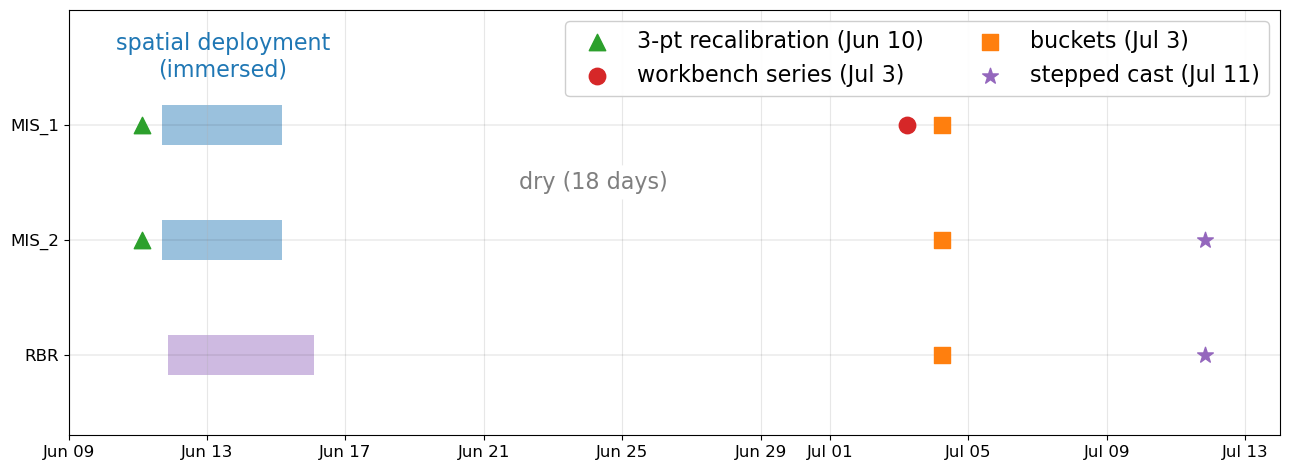

In [9]:
# =============================================================================
# Figure 1 — experiment timeline
# Draws the timeline from the stamps in the CONFIG. Reads no data file.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set
ROWS = [("RBR", 0), ("MIS_2", 1), ("MIS_1", 2)]
DEPLOY_START, DEPLOY_END = pd.Timestamp("2026-06-11T17:00"), pd.Timestamp("2026-06-15T04:00")
RBR_SP_START, RBR_SP_END = pd.Timestamp("2026-06-11T20:53"), pd.Timestamp("2026-06-16T02:18")

fig, ax = plt.subplots(figsize=(13, 4.8))
for name, y in ROWS:
    ax.axhline(y, color="k", lw=0.3, alpha=0.3)

# immersion spans
for y in (1, 2):
    ax.barh(y, (DEPLOY_END - DEPLOY_START).total_seconds() / 86400,
            left=DEPLOY_START, height=0.35, color="tab:blue", alpha=0.45)
ax.barh(0, (RBR_SP_END - RBR_SP_START).total_seconds() / 86400,
        left=RBR_SP_START, height=0.35, color="tab:purple", alpha=0.45)

# EVENTS — remap every row tuple
EVENTS = [(RECAL_TIME_UTC, (1, 2), "^", "tab:green",
           "3-pt recalibration (Jun 10)"),
          (JUL3_LAB_TIME - pd.Timedelta("18h"), (2,), "o", "tab:red",
           "workbench series (Jul 3)"),
          (JUL3_LAB_TIME + pd.Timedelta("6h"), (0, 1, 2), "s",
           "tab:orange", "buckets (Jul 3)"),
          (CAST_TIME_UTC, (0, 1), "*", "tab:purple",
           "stepped cast (Jul 11)")]


seen = set()
for t, rows_, mk, col, lab in EVENTS:
    for y in rows_:
        ax.scatter([t], [y], marker=mk, s=140, color=col, zorder=5,
                   label=lab if lab not in seen else None)
        seen.add(lab)

ax.annotate("spatial deployment\n(immersed)",
            xy=(DEPLOY_START + pd.Timedelta("1D18h"), 2.42),
            fontsize=FS_LABEL, ha="center", color="tab:blue")
# y=1.5 sits between the MIS_2 and MIS_1 guide lines: the dry period applies to
# both units, and at y=1 the MIS_2 guide line ran straight through the text.
ax.annotate("dry (18 days)",
            xy=(DEPLOY_END + pd.Timedelta("9D"), 1.5),
            fontsize=FS_LABEL, ha="center", va="center", color="tab:gray",
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="none"))

ax.set_ylim(-0.7, 3)
ax.set_yticks([y for _, y in ROWS])
ax.set_yticklabels([n for n, _ in ROWS], fontsize=FS_TICK)
ax.set_xlim(pd.Timestamp("2026-06-09"), pd.Timestamp("2026-07-14"))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
ax.tick_params(labelsize=FS_TICK)
# ax.set_title("Experiment timeline, all units (2026, UTC)", fontsize=FS_TITLE)
ax.legend(fontsize=FS_LABEL, loc="upper right", ncol=2, framealpha=0.95)
ax.grid(axis="x", alpha=0.3)
fig.tight_layout()
fig.savefig(PLOT_DIR / "fig01_timeline.png", dpi=DPI)
plt.show()

---
## Figure 3 — Temperature accuracy — 1:1 against the RBR

Panel (a) pools 17 cast-reference pairs, depth-binned. Panel (b) is the static co-location at the same site. 

casts:  1082 depth bins from 17 casts (17 RBR profiles), DZ = 0.1 m
longlog: dropped 1 corrupt record(s)
longlog: 596 x 30s bins, 06-07 07:45 -> 06-07 12:42 PDT (4.96 h)
A  Matched downcasts (0.10 m bins, de n= 1082  bias=-0.0231  sd=0.0323  rmse=0.0397  slope=0.9962  R2=0.9901
B  5.0 h co-deployment (30s means, ti n=  596  bias=-0.0252  sd=0.0056  rmse=0.0258  slope=1.0001  R2=0.9996
wrote plots\fig03_temperature_1to1.png


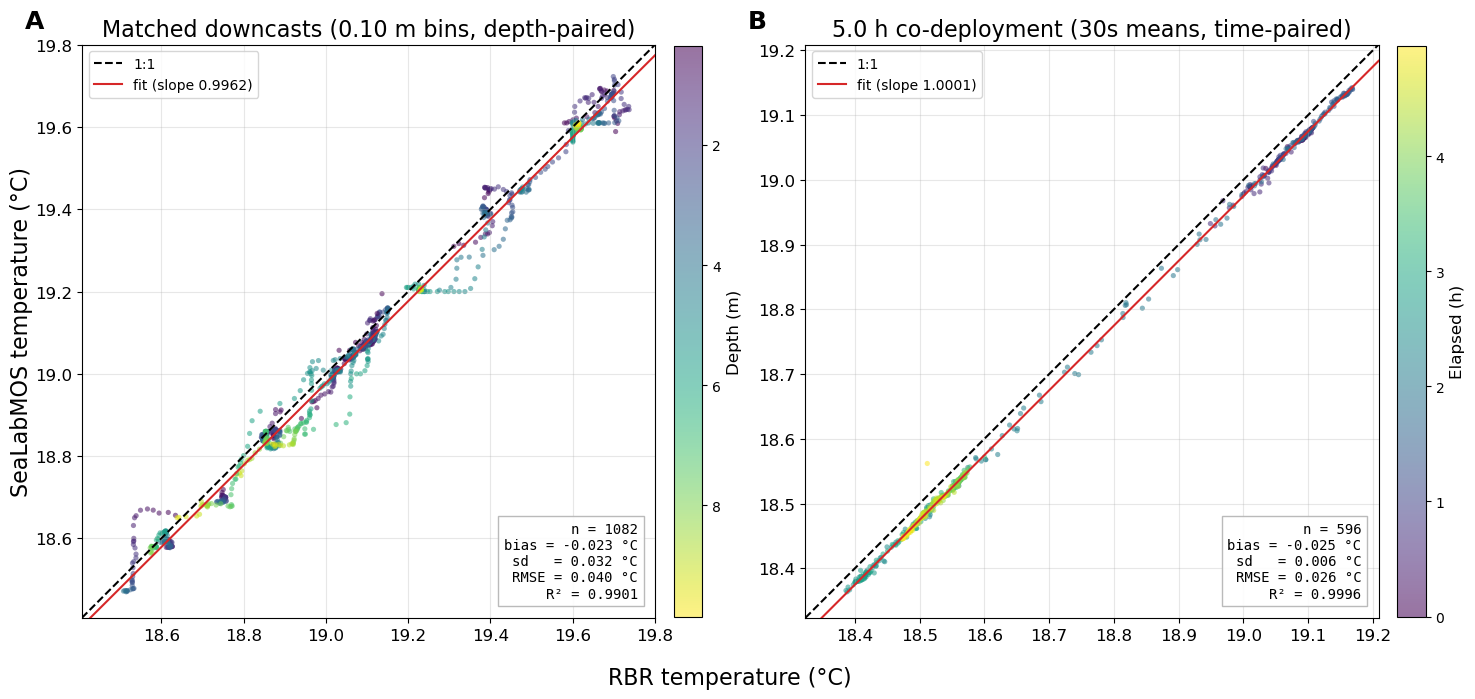

In [10]:
# =============================================================================
# Figure 3 — temperature accuracy against the RBR 1:1
#   A: pooled downcasts   B: 5-hour co-deployment

# Panel (a) pools every matched downcast into 0.10 m depth bins; panel (b) is
# the long co-deployment resampled to 30 s means. Panel (a) is depth-paired,
# panel (b) time-paired.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set
# =============================================================================
# Requires from earlier cells: matched, pairs, orig_dc, rbr_dc, casts, LONG,
#                              ll_rbr, FS_TITLE, FS_LABEL, FS_TICK, save()
# =============================================================================

# ------------------------------- CONFIG --------------------------------------
# Left panel — casts, paired on DEPTH (instruments lowered separately)
DZ            = 0.1     # m, depth bin width
MIN_BIN_N     = 3       # samples per bin, per instrument, to use that bin
SEALAB_DZ_OFF = 0.08    # m, subtracted from slowBRDepth before binning (0.0 = raw)
                        # Set by hand from in-air samples, even tho because it's 
                        # depth binned it doesn't change much

# Right panel — 5-hour co-deployment, paired on TIME (both static, same water, same place)
LL_RESAMPLE   = "30s"   # common time base
LL_ZMIN       = 0.2     # m, both instruments must be below this (drops deck/descent).
                        # The only gate on the co-deployment: the RBR record is
                        # already the profile-split soak segment, so there is no
                        # deployment swing left at the front to trim by hand.
PRES_VALID    = (800.0, 1500.0)   # mbar; rejects corrupt records (one exists at
                                  # 2026-06-07 11:47:22, P = -1.97e7 mbar).
                                  # Rejected on load rather than edited out of
                                  # the raw file, which stays as recorded.

SHARE_LIMITS  = False   # True = identical axes on both panels
CMAP, MS, ALPHA = "viridis", 14, 0.55
PANEL_LABELS = ["A", "B"]        # A = casts, B = co-deployment
PANEL_LAB_XY = (-0.10, 1.02)     # axes coords; nudge x, clips the tick labels
OUTNAME = "fig03_temperature_1to1.png"
# -----------------------------------------------------------------------------

# ---- left: pool the casts on depth bins -------------------------------------
rows = []
for k in matched:
    o = orig_dc[k].copy()
    o["_z"] = o["slowBRDepth"] - SEALAB_DZ_OFF
    for rid in pairs[k]:
        r = rbr_dc_dep[rid]
        zlo, zhi = max(o["_z"].min(), r["depth"].min()), min(o["_z"].max(), r["depth"].max())
        if not np.isfinite([zlo, zhi]).all() or zhi - zlo < DZ:
            print(f"  {k} / {rid}: no usable depth overlap"); continue
        edges = np.arange(np.floor(zlo / DZ) * DZ, zhi + DZ, DZ)
        ob = o.groupby(pd.cut(o["_z"], edges, labels=False))
        rb = r.groupby(pd.cut(r["depth"], edges, labels=False))
        og, rg = ob.mean(numeric_only=True), rb.mean(numeric_only=True)
        keep = og.index.intersection(rg.index)
        keep = keep[(ob.size().reindex(keep) >= MIN_BIN_N) &
                    (rb.size().reindex(keep) >= MIN_BIN_N)]
        if len(keep) == 0:
            print(f"  {k} / {rid}: no bins met MIN_BIN_N"); continue
        rows.append(pd.DataFrame({
            "cast": k, "rbr_id": rid,
            "z": edges[keep.astype(int)] + DZ / 2,
            "o": og.loc[keep, "fastBRTemp"].to_numpy(),
            "r": rg.loc[keep, "temp"].to_numpy()}))

C = pd.concat(rows, ignore_index=True).dropna(subset=["o", "r"])
print(f"casts:  {len(C)} depth bins from {C['cast'].nunique()} casts "
      f"({C['rbr_id'].nunique()} RBR profiles), DZ = {DZ} m")

# ---- right: 5-hour co-deployment on a common time base ----------------------
ll_o = casts_dep[LONG].copy()
for _c in ("fastBRTemp", "slowBRPres", "slowBRDepth"):
    ll_o[_c] = pd.to_numeric(ll_o[_c], errors="coerce")
_ok = (ll_o["slowBRPres"].between(*PRES_VALID) & ll_o["fastBRTemp"].between(-5, 50))
if (~_ok).sum():
    print(f"longlog: dropped {(~_ok).sum()} corrupt record(s)")
ll_o = ll_o[_ok]
o_s = ll_o.loc[ll_o["slowBRDepth"] - SEALAB_DZ_OFF > LL_ZMIN, "fastBRTemp"]
r_s = ll_rbr.loc[ll_rbr["depth"] > LL_ZMIN, "temp"]
L = pd.concat([o_s.resample(LL_RESAMPLE).mean().rename("o"),
               r_s.resample(LL_RESAMPLE).mean().rename("r")],
              axis=1, join="inner").dropna()
L["t_h"] = (L.index - L.index.min()).total_seconds() / 3600.0
print(f"longlog: {len(L)} x {LL_RESAMPLE} bins, "
      f"{L.index.min():%m-%d %H:%M} -> {L.index.max():%m-%d %H:%M} PDT "
      f"({L['t_h'].max():.2f} h)")

# ---- plot -------------------------------------------------------------------
PANELS = [
    {"d": C, "c": C["z"],   "cl": "Depth (m)",        "inv": True,
     "title": f"Matched downcasts ({DZ:.2f} m bins, depth-paired)"},
    {"d": L, "c": L["t_h"], "cl": "Elapsed (h)",      "inv": False,
     "title": f"{L['t_h'].max():.1f} h co-deployment ({LL_RESAMPLE} means, time-paired)"},
]

if SHARE_LIMITS:
    a = np.concatenate([P["d"][["o", "r"]].to_numpy().ravel() for P in PANELS])
    pad = 0.05 * (a.max() - a.min())
    shared = (a.min() - pad, a.max() + pad)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for i, (ax, P) in enumerate(zip(axes, PANELS)):
    x, y, c = P["d"]["r"].to_numpy(), P["d"]["o"].to_numpy(), P["c"].to_numpy()
    resid = y - x
    bias, sd = resid.mean(), resid.std()
    rmse = np.sqrt((resid ** 2).mean())
    slope, icpt = np.polyfit(x, y, 1)
    r2 = np.corrcoef(x, y)[0, 1] ** 2

    if SHARE_LIMITS:
        lim = shared
    else:
        lo, hi = min(x.min(), y.min()), max(x.max(), y.max())
        pad = 0.05 * (hi - lo); lim = (lo - pad, hi + pad)

    sc = ax.scatter(x, y, c=c, s=MS, alpha=ALPHA, cmap=CMAP, edgecolors="none")
    ax.plot(lim, lim, "k--", lw=1.5, zorder=3, label="1:1")
    ax.plot(np.array(lim), slope * np.array(lim) + icpt, "-", color="#d62728",
            lw=1.5, zorder=3, label=f"fit (slope {slope:.4f})")
    ax.set_xlim(lim); ax.set_ylim(lim); ax.set_aspect("equal", "box")
    ax.set_title(P["title"], fontsize=FS_LABEL)
    ax.tick_params(labelsize=FS_TICK); ax.grid(alpha=0.3)
    ax.legend(fontsize=FS_TICK - 2, loc="upper left")
    ax.text(*PANEL_LAB_XY, PANEL_LABELS[i], transform=ax.transAxes,
            fontsize=FS_TITLE, fontweight="bold", ha="left", va="bottom")
    ax.text(0.97, 0.03,
            f"n = {len(x)}\nbias = {bias:+.3f} \N{DEGREE SIGN}C\n"
            f"sd   = {sd:.3f} \N{DEGREE SIGN}C\nRMSE = {rmse:.3f} \N{DEGREE SIGN}C\n"
            f"R\N{SUPERSCRIPT TWO} = {r2:.4f}",
            transform=ax.transAxes, ha="right", va="bottom",
            fontsize=FS_TICK - 2, family="monospace",
            bbox=dict(fc="white", ec="0.7", alpha=0.9))

    cb = fig.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
    cb.set_label(P["cl"], fontsize=FS_TICK)
    cb.ax.tick_params(labelsize=FS_TICK - 2)
    if P["inv"]:
        cb.ax.invert_yaxis()

    print(f'{PANEL_LABELS[i]}  {P["title"][:34]:34s} n={len(x):5d}  bias={bias:+.4f}  sd={sd:.4f}  '
          f"rmse={rmse:.4f}  slope={slope:.4f}  R2={r2:.4f}")

# fig.suptitle("SeaLabMOS vs RBRconcerto\N{SUPERSCRIPT THREE} — temperature accuracy",
#              fontsize=FS_TITLE, y=1.00)
sx = fig.supxlabel("RBR temperature (\N{DEGREE SIGN}C)", fontsize=FS_LABEL)
sy = fig.supylabel("SeaLabMOS temperature (\N{DEGREE SIGN}C)", fontsize=FS_LABEL)
fig.tight_layout()

# tight_layout centres supxlabel on the whole figure, which the two colorbars
# skew to the right; re-centre it on the plot axes only.
b0, b1 = axes[0].get_position(), axes[1].get_position()
sx.set_x((b0.x0 + b1.x1) / 2)
sy.set_y((b0.y0 + b0.y1) / 2)
save(fig, OUTNAME)
plt.show()

---
## Figure 4 — Implied EC gain and MIS_1 correction method residuals

Panel (a) implied gain for both units — MIS_1 lab standards drift non-linearly, MIS_2 bucket tests are flat. Panel (b) MIS_1 residuals by correction method. This is the revised F3; the superseded F3 and F5 cells were dropped.

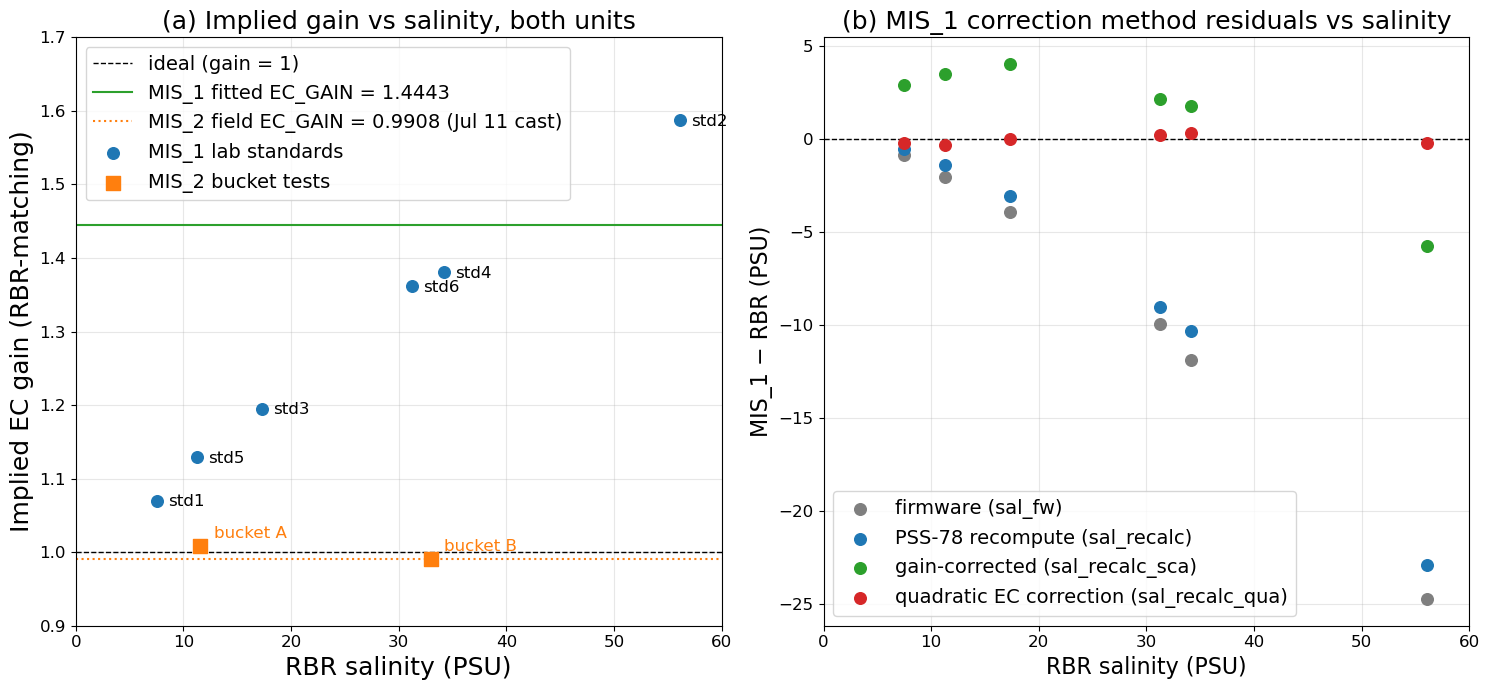

MIS_1 lab implied gain: 1.0699-1.5869 over RBR 7.5-56.1 PSU
        rbr_sal  implied_gain
bucket                       
A       11.5698        1.0079
B       32.9594        0.9908


In [11]:
# =============================================================================
# Figure 4 — implied EC gain and MIS_1 correction method residuals
# Panel (a) is the diagnostic that motivates the correction scheme: a
# scalar gain would plot as a flat line, and MIS_1's does not. MIS_2's bucket
# points sit near 1.0, which is why a scalar suffices for that unit.
# Panel (b) shows what each correction method leaves behind for MIS_1.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

F3_GAIN_YLIM = (0.9,1.7)          # e.g. (0.95, 1.30) to pin panel (a)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 7))

# ---------------- (a) implied gain, both units ----------------
ax1.axhline(1.0, color="k", ls="--", lw=1, label="ideal (gain = 1)")
ax1.axhline(EC_GAIN_MIS1, color="tab:green", ls="-", lw=1.5,
            label=f"MIS_1 fitted EC_GAIN = {EC_GAIN_MIS1:.4f}")
ax1.axhline(EC_GAIN_MIS2, color="tab:orange", ls=":", lw=1.5,
            label=f"MIS_2 field EC_GAIN = {EC_GAIN_MIS2:.4f} (Jul 11 cast)")

ax1.scatter(cal["rbr_sal"], cal["implied_gain"], color="tab:blue",
            s=70, zorder=3, label="MIS_1 lab standards")
for std, row in cal.iterrows():
    ax1.annotate(std, (row["rbr_sal"], row["implied_gain"]),
                 textcoords="offset points", xytext=(8, -4),
                 fontsize=FS_ANNOT)

ax1.scatter(mis2_buckets["rbr_sal"], mis2_buckets["implied_gain"],
            color="tab:orange", marker="s", s=110, zorder=4,
            label="MIS_2 bucket tests")
for label, row in mis2_buckets.iterrows():
    ax1.annotate(f"bucket {label}", (row["rbr_sal"], row["implied_gain"]),
                 textcoords="offset points", xytext=(10, 6),
                 fontsize=FS_ANNOT, color="tab:orange")

ax1.set_xlabel("RBR salinity (PSU)", fontsize=FS_TITLE)
ax1.set_ylabel("Implied EC gain (RBR-matching)", fontsize=FS_TITLE)
ax1.set_title("(a) Implied gain vs salinity, both units", #(flat = scalar model valid)"
              fontsize=FS_TITLE)
ax1.tick_params(labelsize=FS_TICK)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=FS_LEGEND, loc="upper left")
ax1.set_xlim(SCATTER_MIN, SCATTER_MAX)
if F3_GAIN_YLIM:
    ax1.set_ylim(*F3_GAIN_YLIM)

# ---------------- (b) MIS_1 residuals ----------------
ax2.axhline(0.0, color="k", ls="--", lw=1)
for col in METHODS:
    ax2.scatter(cal["rbr_sal"], cal[col] - cal["rbr_sal"],
                color=METHOD_COLORS[col], s=70, zorder=3,
                label=METHOD_LABELS[col])
ax2.set_xlabel("RBR salinity (PSU)", fontsize=FS_LABEL)
ax2.set_ylabel("MIS_1 − RBR (PSU)", fontsize=FS_LABEL)
ax2.set_title("(b) MIS_1 correction method residuals vs salinity", fontsize=FS_TITLE)
ax2.tick_params(labelsize=FS_TICK)
ax2.grid(alpha=0.3)
ax2.legend(fontsize=FS_LEGEND, loc="lower left")
ax2.set_xlim(SCATTER_MIN, SCATTER_MAX)

fig.tight_layout()
fig.savefig(PLOT_DIR / "fig04_implied_gain_residuals.png", dpi=DPI)
plt.show()

print(f"MIS_1 lab implied gain: {cal['implied_gain'].min():.4f}"
      f"-{cal['implied_gain'].max():.4f} over RBR "
      f"{cal['rbr_sal'].min():.1f}-{cal['rbr_sal'].max():.1f} PSU")
print(mis2_buckets[["rbr_sal", "implied_gain"]].round(4).to_string())

---
## Figure 5 — Depth vs time, both casts

Cast one at 0.08 m/s median transit, cast two at 0.52 m/s. Holds shaded.

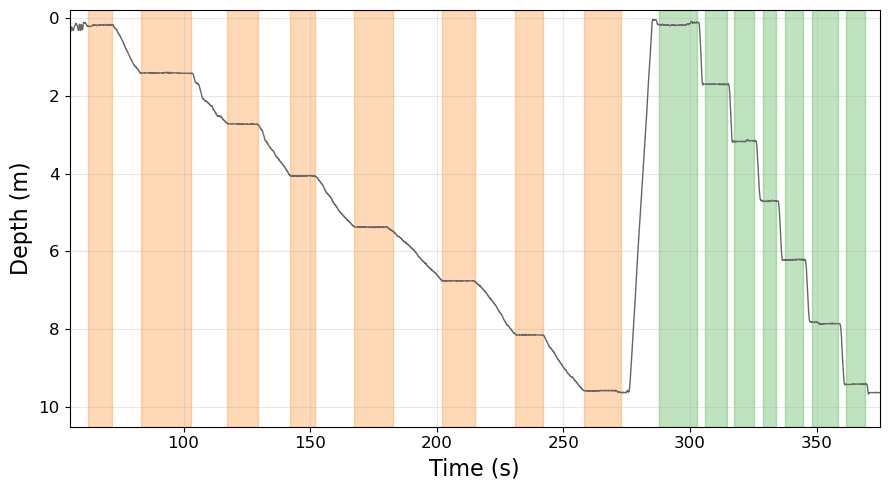

In [29]:
# =============================================================================
# Figure 5 — depth against time for both casts of MIS_2's stepped casts
# Cast one lowered slowly with holds, cast two lowered quickly with holds.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

# limits are done by hand
HOLDS_XLIM = (55, 375)        # time (s)
HOLDS_YLIM = (10.5, -0.2)    # depth (m), inverted

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(mis["t_s"], mis["brDepth"], lw=1, color="0.4")
for _, s in steps.iterrows():
    ax.axvspan(s["t_start"], s["t_start"] + s["dur_s"],
               color=cast_colors[s["cast"]], alpha=0.3)
ax.set_xlim(HOLDS_XLIM); ax.set_ylim(HOLDS_YLIM)
ax.set_xlabel("Time (s)", fontsize=FS_LABEL); ax.set_ylabel("Depth (m)", fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
# ax.set_title("MIS_2 stepped downcasts — detected holds shaded", fontsize=FS_TITLE)
ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PLOT_DIR / "fig05_depth_vs_time.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Figure 6 — Firmware-reported salinity profiles

Firmware (`sal_fw`) only, no RBR overlay — the green streaks are depth updating faster than the EZO's salinity output.

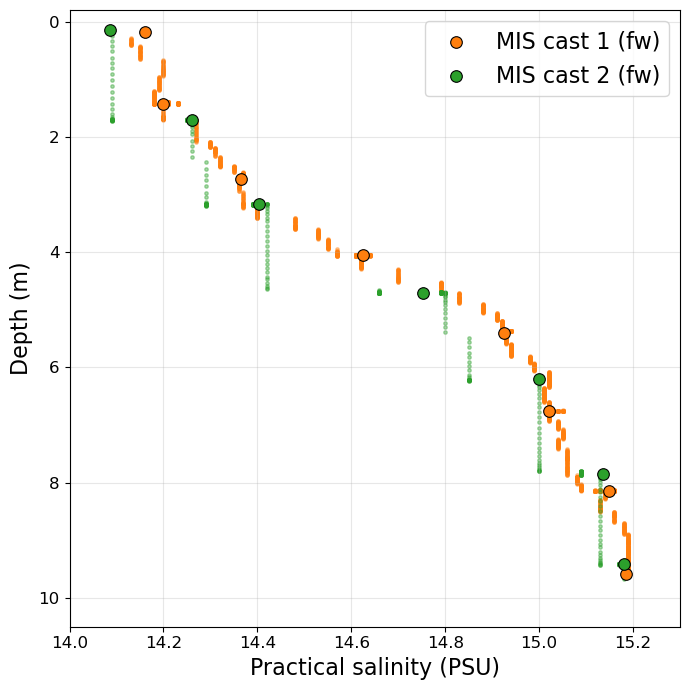

In [13]:
# =============================================================================
# Figure 6 — firmware-reported salinity profiles
# sal_fw only, with no RBR overlay. The green streaks are depth updating
# faster than the EZO's salinity output (the point of the figure).
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

SAL_XLIM   = (14.0, 15.3)    # PSU
SAL_YLIM   = (10.5, -0.2)    # depth (m), inverted

fig, ax = plt.subplots(figsize=(7, 7))
for c, col in cast_colors.items():
    g = mis[mis["cast"] == c]
    ax.scatter(g["sal"], g["brDepth"], s=6, color=col, alpha=0.4)
    st = steps[steps["cast"] == c]
    ax.scatter(st["sal_fw"], st["depth"], marker="o", s=70, color=col,
               edgecolors="k", lw=0.8, zorder=3,
               label=f"MIS cast {c} (fw)")
ax.set_xlim(SAL_XLIM); ax.set_ylim(SAL_YLIM)
ax.set_xlabel("Practical salinity (PSU)", fontsize=FS_LABEL); ax.set_ylabel("Depth (m)", fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
# ax.set_title("Salinity — RBR vs MIS_2 stepped downcasts", fontsize=FS_TITLE)
ax.legend(fontsize=FS_LABEL); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PLOT_DIR / "fig06_firmware_salinity_profiles.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Figure 7 — 1:1, firmware vs recalculated salinity

Hold averages against the RBR. The recalculation reaches RMSE 0.179 PSU.

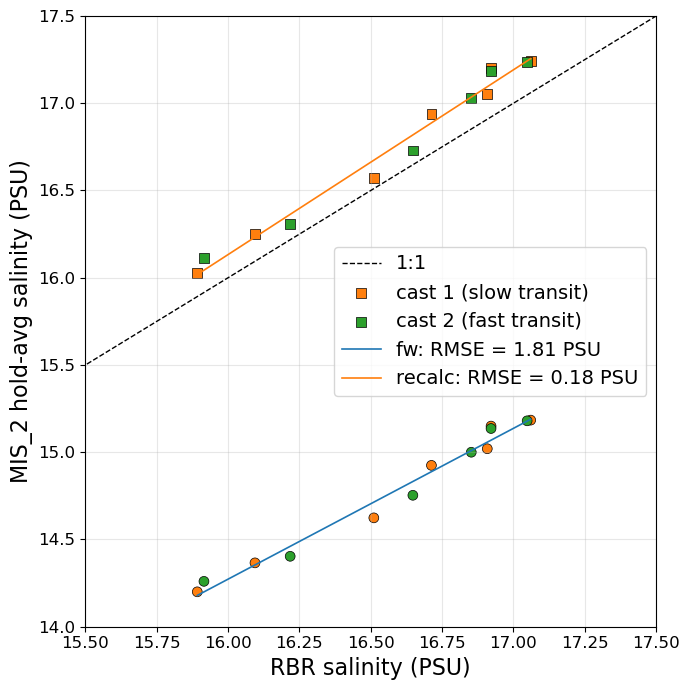

In [14]:
# =============================================================================
# Figure 7 — firmware vs recalculated salinity at the hold points
# 1:1 against the RBR reference each hold was matched to by depth.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set
FIT_XLIM = (15.5, 17.5)    # RBR PSU (main axes: cast cluster)
FIT_YLIM = (14.0, 17.5)    # MIS PSU (main axes: cast cluster)

fig, ax = plt.subplots(figsize=(7, 7))
one2one = np.array([min(FIT_XLIM[0], FIT_YLIM[0]), max(FIT_XLIM[1], FIT_YLIM[1])])
ax.plot(one2one, one2one, "k--", lw=1, label="1:1")
for c, col in cast_colors.items():
    ax.scatter([], [], marker="s", s=50, color=col, edgecolors="k", lw=0.5,
               label=f"cast {c} ({transit[c]})")

for col_name, marker, lbl in [("sal_fw", "o", "fw"), ("sal_recalc", "s", "recalc")]:
    x, y = dc["rbr_sal"].values, dc[col_name].values
    m, b = np.polyfit(x, y, 1)
    r2       = np.corrcoef(x, y)[0, 1] ** 2
    bias     = np.mean(y - x)
    rmse_11  = np.sqrt(np.mean((y - x) ** 2))            # accuracy vs reference
    rmse_fit = np.sqrt(np.mean((y - (m * x + b)) ** 2))  # scatter after linear cal

    ax.scatter(x, y, marker=marker, s=50,
               c=[cast_colors[c] for c in dc["cast"]], edgecolors="k", lw=0.5)
    xf = np.linspace(x.min(), x.max(), 10)
    ax.plot(xf, m * xf + b, lw=1.2,
            # label=f"{lbl}: y = {m:.3f}x {b:+.3f}, RMSE = {rmse_11:.3f} PSU")
            label=f"{lbl}: RMSE = {rmse_11:.2f} PSU")

    # print(f"{lbl}: slope {m:.4f}, intercept {b:+.4f}, R2 {r2:.4f}, "
    #       f"bias {bias:+.4f}, RMSE_1:1 {rmse_11:.4f}, RMSE_fit {rmse_fit:.4f}")

ax.set_xlim(FIT_XLIM); ax.set_ylim(FIT_YLIM)
ax.set_xlabel("RBR salinity (PSU)", fontsize=FS_LABEL)
ax.set_ylabel("MIS_2 hold-avg salinity (PSU)", fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
ax.legend(fontsize=FS_LEGEND,loc="center right"); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PLOT_DIR / "fig07_one2one_fw_vs_recalc.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Figure 8 — EC_GAIN fit with bucket-test insets

Cast holds on the primary axes; insets are the two independent bucket tests at 11.57 and 32.96 PSU.

in-sample fit range: RBR 15.892-17.060 PSU (span 1.168), MIS 15.867-17.068 PSU, n = 13
recalc_g (casts): slope 1.0480, intercept -0.7970, R2 0.9812, bias -0.0007, RMSE_1:1 0.0624, RMSE_fit 0.0593
bucket A: corrected 11.3553, RBR 11.5698, resid -0.2145, extrapolation -4.32 PSU beyond fit range
bucket B: corrected 32.9473, RBR 32.9594, resid -0.0120, extrapolation +15.90 PSU beyond fit range


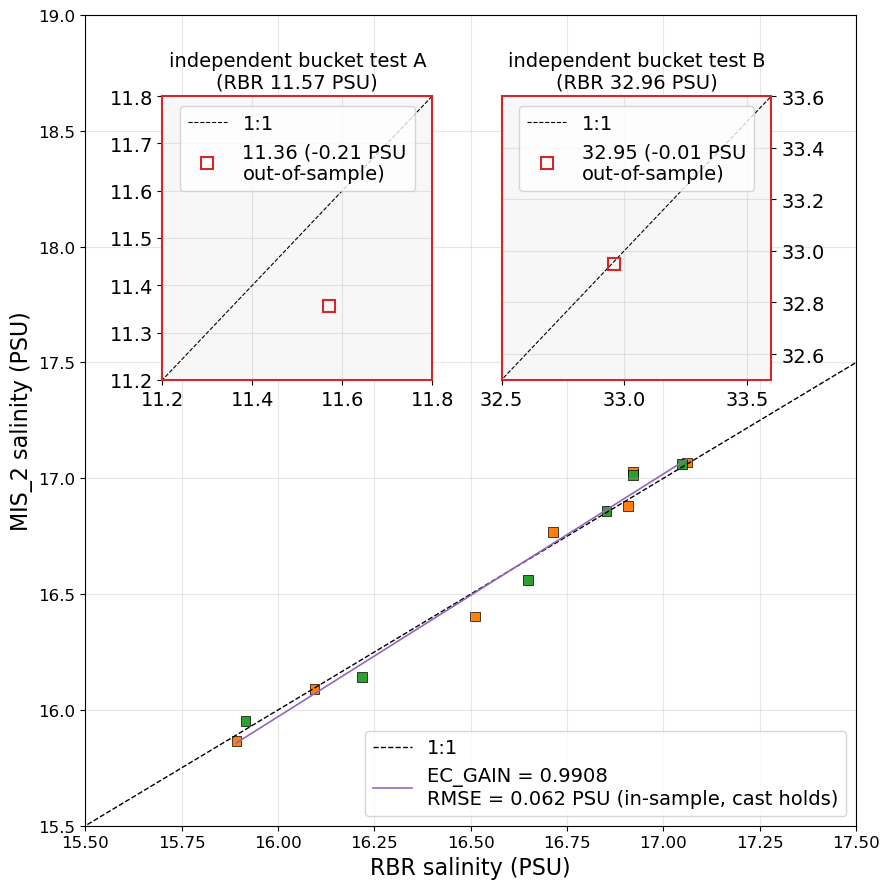

In [15]:
# =============================================================================
# Figure 8 — the MIS_2 gain fit, with both bucket tests as insets
# Main axes: the thirteen hold points, gain-corrected. These are the SAME points
# EC_GAIN_MIS2 was fitted on, so the RMSE printed there is in-sample.
# Insets: the two bucket waters, which took no part in the fit and
# are therefore the out-of-sample test. 
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

CORR_XLIM  = (15.5, 17.5)    # main axes: the cast cluster, gain-corrected
CORR_YLIM  = (15.5, 19)
CORR_INSET = (32.5, 33.6)    # inset axes: bucket B, out-of-sample

fig, ax = plt.subplots(figsize=(9, 9))
ax.plot([0, 40], [0, 40], "k--", lw=1, label="1:1")

x, y = dc["rbr_sal"].values, dc["sal_recalc_g"].values
m, b = np.polyfit(x, y, 1)
r2       = np.corrcoef(x, y)[0, 1] ** 2
bias     = np.mean(y - x)
rmse_11  = np.sqrt(np.mean((y - x) ** 2))            # accuracy vs reference
rmse_fit = np.sqrt(np.mean((y - (m * x + b)) ** 2))  # scatter after linear cal

ax.scatter(x, y, marker="s", s=50,
           c=[cast_colors[c] for c in dc["cast"]], edgecolors="k", lw=0.5)
xf = np.linspace(x.min(), x.max(), 10)
ax.plot(xf, m * xf + b, lw=1.2, color="tab:purple",
        label=(f"EC_GAIN = {EC_GAIN_MIS2:.4f}\n"
               f"RMSE = {rmse_11:.3f} PSU (in-sample, cast holds)"))

ax.set_xlim(CORR_XLIM); ax.set_ylim(CORR_YLIM)
ax.set_xlabel("RBR salinity (PSU)", fontsize=FS_LABEL)
ax.set_ylabel(f"MIS_2 salinity (PSU)", fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
ax.legend(fontsize=FS_LEGEND, loc="lower right")
ax.grid(alpha=0.3)

# --- insets: independent bucket tests, bracketing the fit range ---
# bucketA comes from data/bucketA_MIS_2.csv via the stepped-cast loader, so
# this inset follows DEPTH_ZERO_MODE and the fitted gain instead of being
# pinned to numbers from one particular run.
A_INSET = (11.2, 11.8)

bkt_resid_A = bucketA["mis_recalc_g"] - bucketA["rbr"]
bkt_resid_B = bucketB["mis_recalc_g"] - bucketB["rbr"]

def add_bucket_inset(rect, lims, bkt, resid, name):
    axi = ax.inset_axes(rect)
    axi.plot([0, 40], [0, 40], "k--", lw=0.8, label="1:1")
    axi.plot(bkt["rbr"], bkt["mis_recalc_g"], "s", mfc="none", mec="tab:red",
             ms=8, mew=1.5,
             label=f"{bkt['mis_recalc_g']:.2f} ({resid:+.2f} PSU\nout-of-sample)")
    axi.set_xlim(lims); axi.set_ylim(lims)
    axi.tick_params(labelsize=FS_INSET)
    axi.legend(fontsize=FS_INSET, loc="upper center")
    axi.grid(alpha=0.3)
    axi.set_facecolor("0.97")
    axi.set_title(f"independent bucket test {name}\n(RBR {bkt['rbr']:.2f} PSU)",
                  fontsize=FS_INSET)
    for spine in axi.spines.values():
        spine.set_edgecolor("tab:red")
        spine.set_linewidth(1.5)
    return axi

axi_A = add_bucket_inset([0.1, 0.55, 0.35, 0.35], A_INSET, bucketA, bkt_resid_A, "A")
axi_B = add_bucket_inset([0.54, 0.55, 0.35, 0.35], CORR_INSET, bucketB, bkt_resid_B, "B")
axi_B.yaxis.set_label_position("right")
axi_B.yaxis.tick_right()

print(f"in-sample fit range: RBR {x.min():.3f}-{x.max():.3f} PSU "
      f"(span {x.max()-x.min():.3f}), MIS {y.min():.3f}-{y.max():.3f} PSU, n = {len(x)}")
print(f"recalc_g (casts): slope {m:.4f}, intercept {b:+.4f}, R2 {r2:.4f}, "
      f"bias {bias:+.4f}, RMSE_1:1 {rmse_11:.4f}, RMSE_fit {rmse_fit:.4f}")
print(f"bucket A: corrected {bucketA['mis_recalc_g']:.4f}, "
      f"RBR {bucketA['rbr']:.4f}, resid {bkt_resid_A:+.4f}, "
      f"extrapolation {bucketA['rbr'] - x.min():+.2f} PSU beyond fit range")
print(f"bucket B: corrected {bucketB['mis_recalc_g']:.4f}, "
      f"RBR {bucketB['rbr']:.4f}, resid {bkt_resid_B:+.4f}, "
      f"extrapolation {bucketB['rbr'] - x.max():+.2f} PSU beyond fit range")

plt.tight_layout()
fig.savefig(PLOT_DIR / "fig08_ec_gain_bucket_insets.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Figure 9 — Four salinity correction methods vs the RBR reference

MIS_1 workbench testing, 2x2. Panel (d) is the quadratic correction.

MIS_1 salinity corrections
  EC gain      : 1.444266
                 EC_corr = 1.4443 * EC_raw
  Quadratic    : A1 = +0.86331   A2 = +0.0149285
                 EC_corr = 0.86331*C +0.0149285*C^2


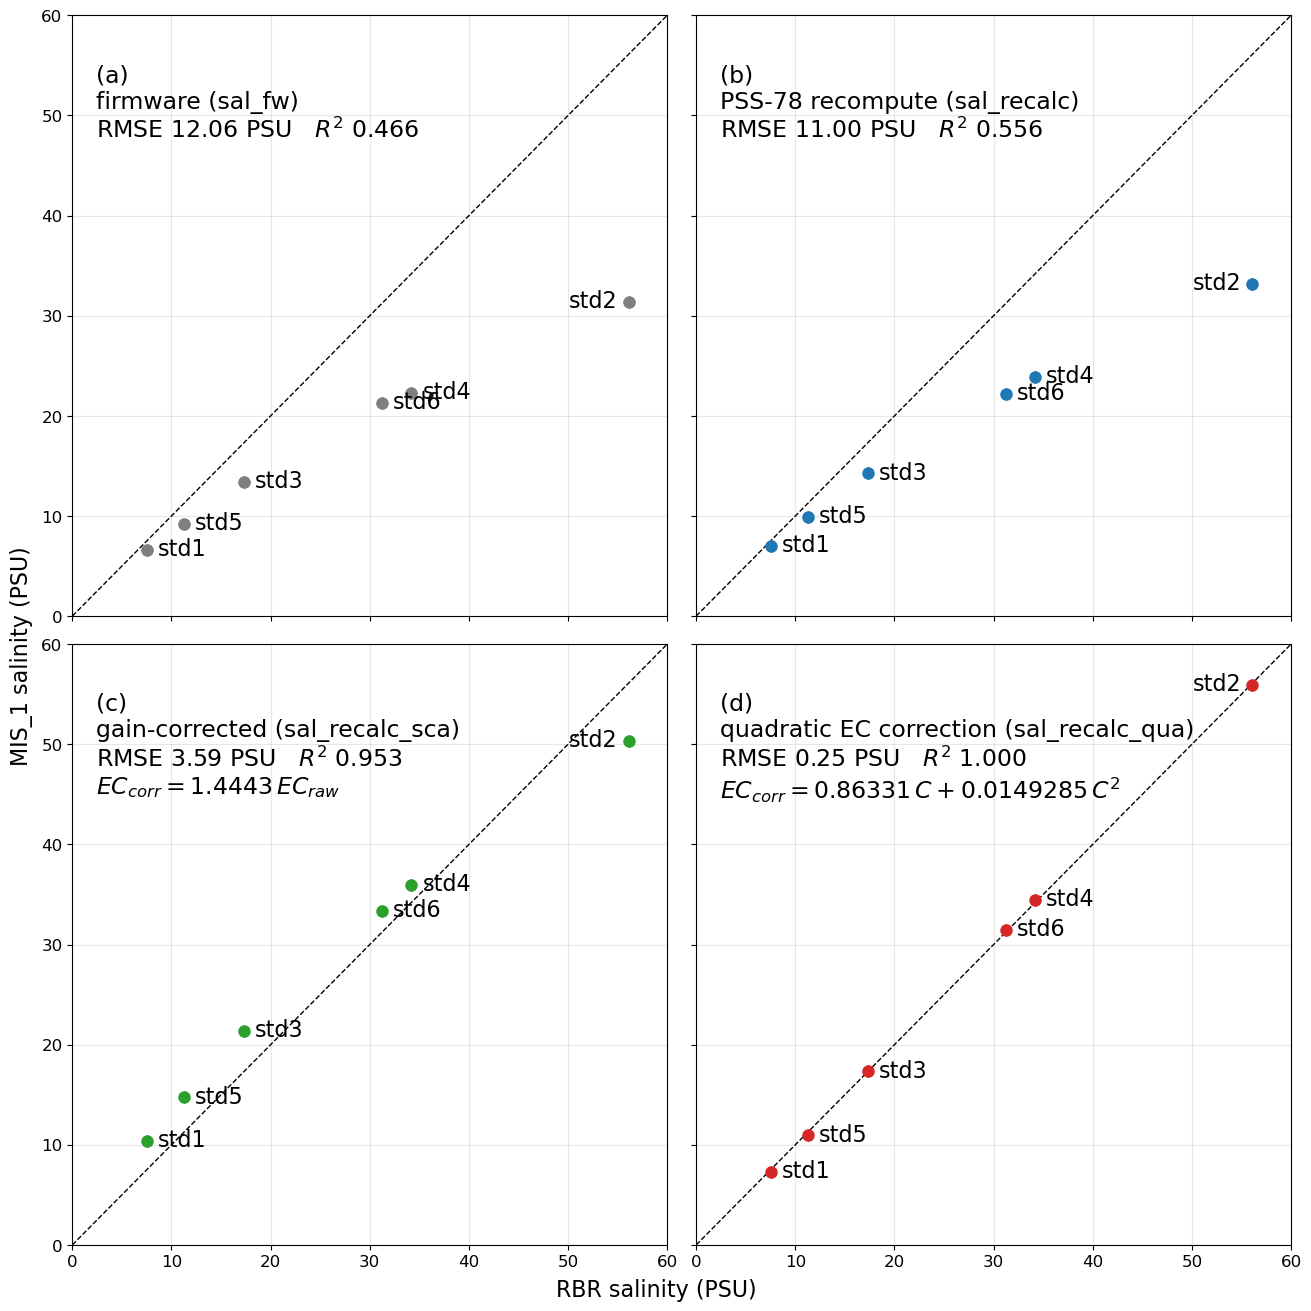

In [16]:
# =============================================================================
# Figure 9 — four salinity correction methods against the RBR
# MIS_1 workbench standards, one panel per correction method, progressively shown.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

def print_corrections():
    print("=" * 56)
    print("MIS_1 salinity corrections")
    print("=" * 56)
    print(f"  EC gain      : {EC_GAIN_MIS1:.6f}")
    print(f"                 {gain_eqn()}")
    print(f"  Quadratic    : A1 = {A1:+.5f}   A2 = {A2:+.7f}")
    print(f"                 {quad_eqn()}")
    print("=" * 56)

print_corrections()

# Which panel carries which equation. Keys MUST be column names from METHODS;
# they previously were not, so `col in METHOD_EQNS` never matched and neither
# equation was ever drawn.
METHOD_EQNS = {
    "sal_recalc_sca": gain_eqn(math=True),
    "sal_recalc_qua": quad_eqn(math=True),
}


LABEL_FLIP_FRAC = 0.85   # points past this fraction of the x-range get left-side labels
x_flip = SCATTER_MIN + LABEL_FLIP_FRAC * (SCATTER_MAX - SCATTER_MIN)

fig, axes = plt.subplots(2, 2, figsize=(13, 13),
                         sharex=True, sharey=True,
                         constrained_layout=True)

for ax, col, letter in zip(axes.flat, METHODS, "abcd"):
    ax.plot([SCATTER_MIN, SCATTER_MAX], [SCATTER_MIN, SCATTER_MAX],
            "k--", lw=1)
    ax.errorbar(cal["rbr_sal"], cal[col], xerr=cal["rbr_sal_std"],
                yerr=cal["sal_fw_std"] if col == "sal_fw" else None,
                fmt="o", color=METHOD_COLORS[col], ms=8, capsize=4)
    for std, row in cal.iterrows():
        flip = row["rbr_sal"] > x_flip
        ax.annotate(std, (row["rbr_sal"], row[col]),
                    textcoords="offset points",
                    xytext=(-8, -4) if flip else (8, -4),
                    ha="right" if flip else "left",
                    fontsize=FS_LABEL)
    s = METHOD_STATS[col]
    txt = (f"({letter})\n{METHOD_LABELS[col]}\n"
           f"RMSE {s['rmse']:.2f} PSU   $R^2$ {s['r2']:.3f}")
    if col in METHOD_EQNS:
        txt += f"\n{METHOD_EQNS[col]}"
    ax.annotate(txt, xy=(0.04, 0.92), xycoords="axes fraction",
                fontsize=FS_LABEL+1, va="top")
    ax.set_xlim(SCATTER_MIN, SCATTER_MAX)
    ax.set_ylim(SCATTER_MIN, SCATTER_MAX)
    ax.tick_params(labelsize=FS_TICK)
    ax.grid(alpha=0.3)

fig.supxlabel("RBR salinity (PSU)", fontsize=FS_LABEL)
fig.supylabel("MIS_1 salinity (PSU)", fontsize=FS_LABEL)
# fig.suptitle(f"MIS_1 salinity correction methods vs reference "
#              f"(EC_GAIN = {EC_GAIN_MIS1:.4f}; quad = {A1:.3f}C {A2:+.5f}C$^2$)",
#              fontsize=FS_TITLE)
fig.savefig(PLOT_DIR / "fig09_correction_method_progression.png", dpi=DPI)
plt.show()

---
## Figure 10 — Out-of-sample bucket validation, both units

Panel (a) MIS_1 quadratic refit on 4 standards with both bucket waters held out. Panel (b) MIS_2 scalar gain, buckets independent of the fit.

bucket -> lab standard (verify): {'A': 'std5', 'B': 'std4'}
quad all-6       : A1 +0.86331  A2 +0.0149285
quad leave-2-out : A1 +0.85809  A2 +0.0150984   (A2 shift +1.1% -- large = quad leans on the held-out points)

MIS_1 retained standards (in-sample)  bias -0.254  RMSE 0.400 mS/cm
       c_rbr   c_raw   c_cor    res    pct
pt                                        
std1  12.475  11.625  12.016 -0.460 -3.685
std2  76.907  48.130  76.276 -0.631 -0.821
std3  26.597  22.219  26.520 -0.077 -0.290
std6  46.393  33.956  46.546  0.153  0.330

MIS_1 buckets (out-of-sample)  bias -0.736  RMSE 0.743 mS/cm
     c_rbr   c_raw   c_cor    res    pct
pt                                      
A   18.661  16.321  18.026 -0.635 -3.402
B   49.083  34.852  48.245 -0.838 -1.707

MIS_2 buckets (scalar)  bias -0.098  RMSE 0.815 mS/cm
     c_rbr   c_raw   c_cor    res    pct
pt                                      
A   18.661  17.919  17.754 -0.907 -4.858
B   49.083  50.256  49.794  0.711  1.449


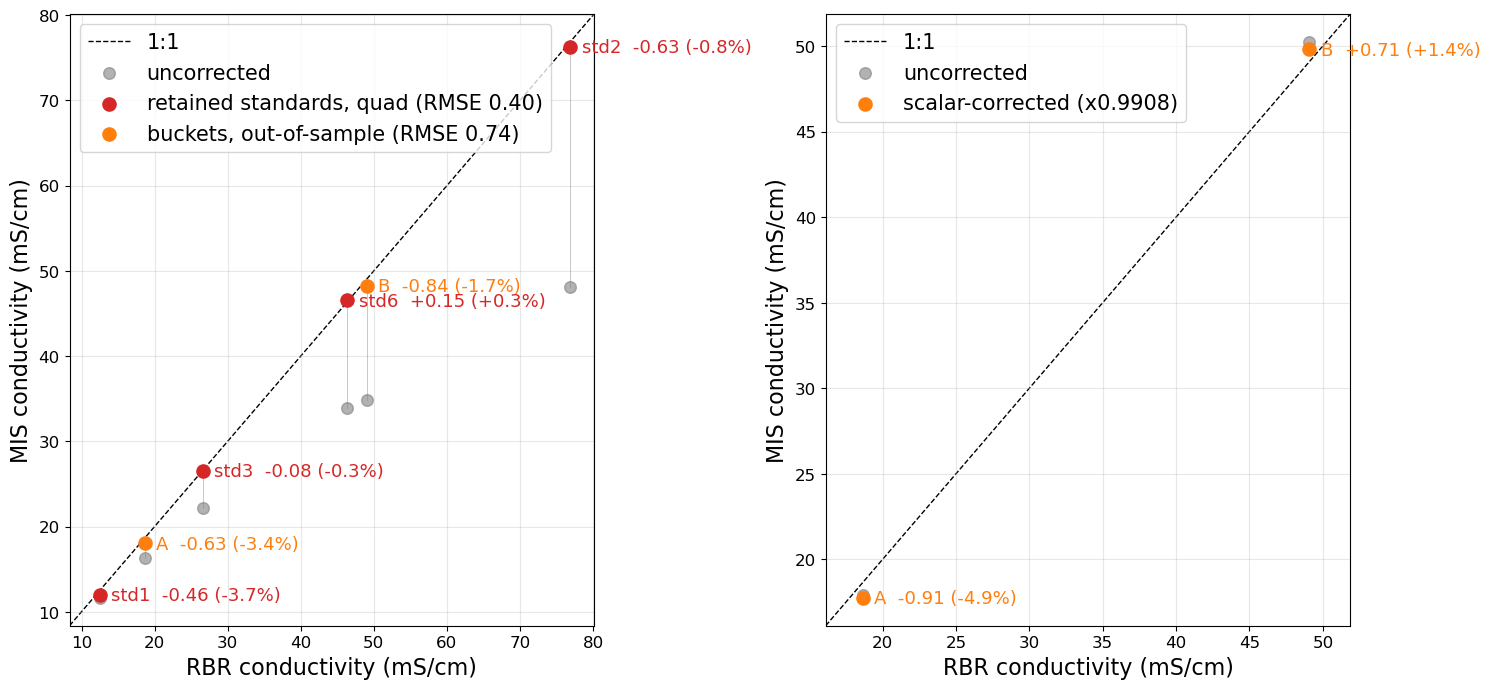

In [17]:
# =============================================================================
# Figure 10 — out-of-sample bucket validation, both MIS_1 and MIS_2
# Panel (a) refits the MIS_1 quadratic on four standards with both bucket
# waters held out, so the buckets are genuinely out of sample. Panel (b) is
# MIS_2's scalar gain against its buckets, which were never in its fit.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

# ---- knobs -----------------------------------------------------------------
RBR_COND_COL = "cond"                   # column name in the RBR frames
BUCKET_STD = {"A": None, "B": None}     # None = auto-map by nearest RBR salinity; else "stdN"

# ---- dependency guards -----------------------------------------------------
for nm in ("cal", "rbr_lab", "STANDARDS", "rbr_bucket",
           "RBR_BUCKET_WINDOWS", "MIS1_BUCKETS", "MIS2_BUCKETS"):
    if nm not in globals():
        raise RuntimeError(f"need {nm!r} -- run CONFIG, lab-series and bucket cells first")
for df, tag in ((rbr_lab, "rbr_lab"), (rbr_bucket, "rbr_bucket")):
    if RBR_COND_COL not in df.columns:
        raise KeyError(f"{RBR_COND_COL!r} not in {tag} {list(df.columns)} -- "
                       f"add it to the cols dict in load_rbr_nc and re-run that loader")

# ---- RBR conductivity + salinity per bucket (shared by both units) ----------
bk = {}
for label, win in RBR_BUCKET_WINDOWS.items():
    sl = rbr_bucket.loc[win[0]:win[1]]
    bk[label] = {"c_rbr": sl[RBR_COND_COL].mean(),
                 "s_rbr": sl["sal"].mean()}

# ---- map buckets to standards, then leave-2-out refit -----------------------
for label in bk:
    if BUCKET_STD[label] is None:
        BUCKET_STD[label] = (cal["rbr_sal"] - bk[label]["s_rbr"]).abs().idxmin()
print("bucket -> lab standard (verify):", {k: BUCKET_STD[k] for k in bk})
if len(set(BUCKET_STD.values())) < len(BUCKET_STD):
    print("!! two buckets mapped to the same standard -- set BUCKET_STD manually")
held_out = sorted(set(BUCKET_STD.values()))
retained = [s for s in cal.index if s not in held_out]

# Same fit_quad the published A1/A2 came from, same x0, different row subset.
A1_full, A2_full = fit_quad(cal, x0=(EC_GAIN_MIS1, 0.0))            # shift diagnostic only
A1_lo,  A2_lo    = fit_quad(cal.loc[retained], x0=(EC_GAIN_MIS1, 0.0))  # 4-point quad, left panel
print(f"quad all-6       : A1 {A1_full:+.5f}  A2 {A2_full:+.7f}")
print(f"quad leave-2-out : A1 {A1_lo:+.5f}  A2 {A2_lo:+.7f}   "
      f"(A2 shift {100*(A2_lo-A2_full)/abs(A2_full):+.1f}% -- large = quad leans on the held-out points)")

def _resid(df):
    df["res"] = df["c_cor"] - df["c_rbr"]
    df["pct"] = 100 * df["res"] / df["c_rbr"]
    return df

# ---- (A-left) 4 retained standards, 4-pt quad (IN-SAMPLE, red) --------------
rows = []
for label, mw, rw in STANDARDS:
    if label not in retained:
        continue
    c_rbr = rbr_lab.loc[rw[0]:rw[1], RBR_COND_COL].mean()
    ec = cal.loc[label, "ec"]
    rows.append({"pt": label, "c_rbr": c_rbr, "c_raw": ec_to_C(ec),
                 "c_cor": apply_quad(ec_to_C(ec), A1_lo, A2_lo)})
std_ret = _resid(pd.DataFrame(rows).set_index("pt"))

# ---- (A-left) 2 buckets, 4-pt quad (OUT-OF-SAMPLE, orange) ------------------
rows = []
for label, path in MIS1_BUCKETS.items():
    ec = load_mis_csv(path)["ec"].mean()
    rows.append({"pt": label, "c_rbr": bk[label]["c_rbr"],
                 "c_raw": ec_to_C(ec), "c_cor": apply_quad(ec_to_C(ec), A1_lo, A2_lo)})
lab = _resid(pd.DataFrame(rows).set_index("pt"))

# ---- (B-right) MIS_2 buckets, scalar gain (unchanged) ----------------------
rows = []
for label, _path in MIS2_BUCKETS.items():
    C_raw = float(ec_to_C(load_mis_csv(_path)["ec"].mean()))
    rw = RBR_BUCKET_WINDOWS[label]
    c_rbr = rbr_bucket.loc[rw[0]:rw[1], RBR_COND_COL].mean()
    rows.append({"pt": label, "c_rbr": c_rbr, "c_raw": C_raw,
                 "c_cor": EC_GAIN_MIS2 * C_raw})
buck = _resid(pd.DataFrame(rows).set_index("pt"))

# ---- stats -----------------------------------------------------------------
for name, df in [("MIS_1 retained standards (in-sample)", std_ret),
                 ("MIS_1 buckets (out-of-sample)", lab),
                 ("MIS_2 buckets (scalar)", buck)]:
    print(f"\n{name}  bias {df['res'].mean():+.3f}  "
          f"RMSE {np.sqrt((df['res']**2).mean()):.3f} mS/cm")
    print(df.round(3).to_string())

# ---- figure ----------------------------------------------------------------
def _panel(ax, series, letter, subtitle):
    allv = pd.concat([pd.concat([s["df"]["c_rbr"], s["df"]["c_raw"], s["df"]["c_cor"]])
                      for s in series])
    lo, hi = allv.min(), allv.max(); pad = 0.05 * (hi - lo); lims = [lo - pad, hi + pad]
    ax.plot(lims, lims, "k--", lw=1, zorder=1, label="1:1")
    raw_done = False
    for s in series:
        df = s["df"]
        for k, r in df.iterrows():
            ax.plot([r["c_rbr"]] * 2, [r["c_raw"], r["c_cor"]],
                    color="k", lw=0.5, alpha=0.3, zorder=2)
        ax.scatter(df["c_rbr"], df["c_raw"], s=70, color="tab:gray", alpha=0.6,
                   zorder=3, label=None if raw_done else "uncorrected")
        raw_done = True
        ax.scatter(df["c_rbr"], df["c_cor"], s=90, color=s["color"], zorder=4,
                   label=s["label"])
        for k, r in df.iterrows():
            ax.annotate(f"{k}  {r['res']:+.2f} ({r['pct']:+.1f}%)",
                        (r["c_rbr"], r["c_cor"]), textcoords="offset points",
                        xytext=(8, -4), fontsize=FS_ANNOT+1, color=s["color"])
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("RBR conductivity (mS/cm)", fontsize=FS_LABEL)
    ax.set_ylabel("MIS conductivity (mS/cm)", fontsize=FS_LABEL)
    # ax.set_title(f"{letter}. {subtitle}", fontsize=FS_TITLE, loc="left")
    ax.tick_params(labelsize=FS_TICK); ax.grid(alpha=0.3)
    ax.legend(fontsize=FS_LABEL-1, loc="upper left")

fig, (axL, axR) = plt.subplots(1, 2, figsize=(15, 7))
_panel(axL,
       [{"df": std_ret, "color": "tab:red",
         "label": f"retained standards, quad (RMSE {np.sqrt((std_ret['res']**2).mean()):.2f})"},
        {"df": lab, "color": "tab:orange",
         "label": f"buckets, out-of-sample (RMSE {np.sqrt((lab['res']**2).mean()):.2f})"}],
       "A", "MIS_1 quadratic (4-pt leave-2-out)\nstandards in-sample, buckets out-of-sample")
_panel(axR,
       [{"df": buck, "color": "tab:orange",
         "label": f"scalar-corrected (x{EC_GAIN_MIS2:.4f})"}],
       "B", "MIS_2 scalar, bucket tests\n(independent of the Jul-11 cast fit)")

fig.tight_layout()
fig.savefig(PLOT_DIR / "fig10_buckets_out_of_sample.png", dpi=DPI)
plt.show()

---
## Figure 11 — Salinity profiles — RBR, firmware and recalculated

Both casts with the RBR overlay and both firmware and recalculated hold points.

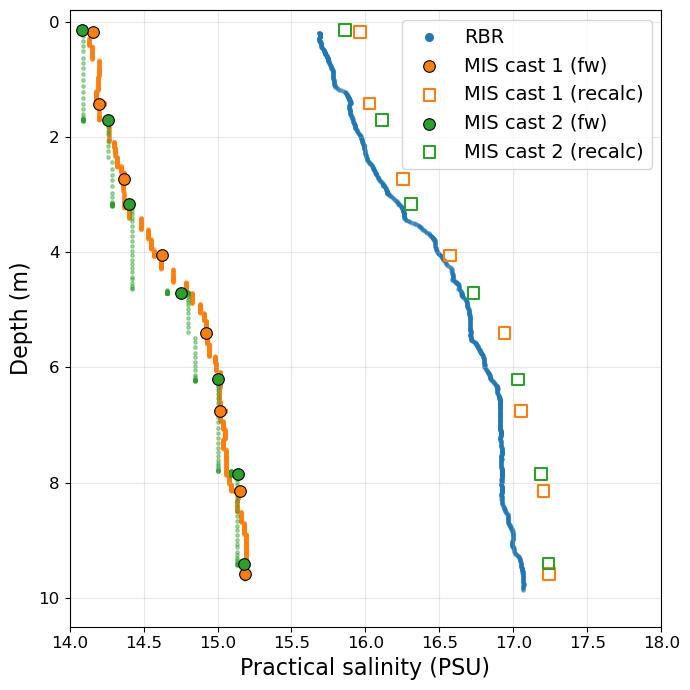

In [18]:
# =============================================================================
# Figure 11 — salinity profiles with the RBR overlaid
# Both casts, firmware and recalculated, against the RBR profile.
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

SAL_XLIM   = (14.0, 18)    # PSU
SAL_YLIM   = (10.5, -0.2)    # depth (m), inverted

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(rbr_plot["salinity"], rbr_plot["depth"], s=6, color="tab:blue", alpha=0.4)
ax.scatter([], [], s=30, color="tab:blue", label="RBR")
for c, col in cast_colors.items():
    g = mis[mis["cast"] == c]
    ax.scatter(g["sal"], g["brDepth"], s=6, color=col, alpha=0.4)
    st = steps[steps["cast"] == c]
    ax.scatter(st["sal_fw"], st["depth"], marker="o", s=70, color=col,
               edgecolors="k", lw=0.8, zorder=3,
               label=f"MIS cast {c} (fw)")
    ax.scatter(st["sal_recalc"], st["depth"], marker="s", s=70,
               facecolors="none", edgecolors=col, lw=1.5, zorder=3,
               label=f"MIS cast {c} (recalc)")
ax.set_xlim(SAL_XLIM); ax.set_ylim(SAL_YLIM)
ax.set_xlabel("Practical salinity (PSU)", fontsize=FS_LABEL); ax.set_ylabel("Depth (m)", fontsize=FS_LABEL)
ax.tick_params(labelsize=FS_TICK)
# ax.set_title("Salinity — RBR vs MIS_2 stepped downcasts", fontsize=FS_TITLE)
ax.legend(fontsize=FS_LEGEND); ax.grid(alpha=0.3)
plt.tight_layout()
fig.savefig(PLOT_DIR / "fig11_salinity_profiles_casts.png", dpi=SAVE_DPI, bbox_inches="tight")
plt.show()

---
## Figure 12 — GOFS 3.1 vertical levels

20 of the 40 standard levels sit in the upper 100 m.

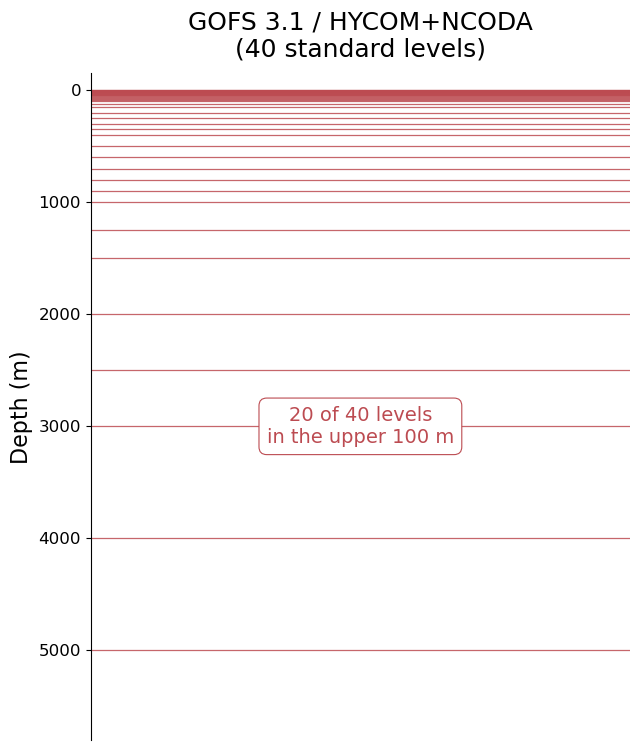

GOFS 3.1 40: n<=100m = 20, min dz = 2 m, max dz = 1000 m, dz(0-50m) = 3.6 m mean, dz(>2000m) = 750 m mean


In [19]:
# =============================================================================
# Figure 12 — GOFS 3.1 vertical levels
# A transcribed level list, no data file. The printed line reproduces the
# figure's caption numbers so they can be checked against the text.
# https://www.hycom.org/dataserver/gofs-3pt1/analysis).
# =============================================================================
fonts()   # reset the six FS_* globals to the canonical set

GOFS40 = np.array([0, 2, 4, 6, 8, 10, 12, 15, 20, 25, 30, 35, 40, 45, 50, 60,
                   70, 80, 90, 100, 125, 150, 200, 250, 300, 350, 400, 500,
                   600, 700, 800, 900, 1000, 1250, 1500, 2000, 2500, 3000,
                   4000, 5000], dtype=float)

LEVEL_COLOR = "#bc4b51"

fig, ax = plt.subplots(figsize=(6.5, 8))

for d in GOFS40:
    ax.axhline(d, color=LEVEL_COLOR, lw=0.9, alpha=0.85)

ax.set_ylim(5800, -150)
ax.set_xlim(0, 1)
ax.set_xticks([])
ax.set_title("GOFS 3.1 / HYCOM+NCODA\n(40 standard levels)", fontsize=FS_TITLE, pad=12)
ax.set_ylabel("Depth (m)", fontsize=FS_LABEL)
ax.tick_params(axis="y", labelsize=FS_TICK)

n_top = int((GOFS40 <= 100).sum())
ax.text(0.5, 3000, f"{n_top} of {GOFS40.size} levels\nin the upper 100 m",
        ha="center", va="center", fontsize=FS_INSET, color=LEVEL_COLOR,
        bbox=dict(boxstyle="round,pad=0.4", fc="white", ec=LEVEL_COLOR, lw=0.8))

for s in ("top", "right", "bottom"):
    ax.spines[s].set_visible(False)

fig.tight_layout(rect=[0, 0.05, 1, 1])
fig.savefig(PLOT_DIR / "fig12_gofs_vertical_levels.png", dpi=DPI)
plt.show()

# --- numbers for the caption / text ------------------------------------------
dz = np.diff(GOFS40)
print(f"GOFS 3.1 40: n<=100m = {(GOFS40 <= 100).sum()}, "
      f"min dz = {dz.min():.0f} m, max dz = {dz.max():.0f} m, "
      f"dz(0-50m) = {dz[GOFS40[:-1] < 50].mean():.1f} m mean, "
      f"dz(>2000m) = {dz[GOFS40[:-1] >= 2000].mean():.0f} m mean")